In [1]:
import json

# 1. Load the evidences dictionary
with open('release_evidences.json', 'r', encoding='utf-8') as f:
    evidences = json.load(f)

total_columns = 0
binary_count = 0
complex_count = 0
skipped_baselines = 0

print("--- ANALYZING FEATURE SPACE ---")

for code, details in evidences.items():
    data_type = details.get('data_type')
    
    # Handle Binary (B) Evidence (e.g., Do you have a cough?)
    if data_type == 'B':
        total_columns += 1
        binary_count += 1
        
    # Handle Categorical (C) or Multi-choice (M) Evidence (e.g., Pain location)
    elif data_type in ['C', 'M']:
        complex_count += 1
        default_val = details.get('default_value')
        possible_values = details.get('possible-values', [])
        
        for val in possible_values:
            # Drop the baseline column as we discussed
            if val == default_val:
                skipped_baselines += 1
                continue
            
            # Every other possible value gets its own column
            total_columns += 1

print(f"Total Base Features (Questions): {len(evidences)}")
print(f"Total Binary Features: {binary_count}")
print(f"Total Complex Features Unrolled: {complex_count}")
print(f"Total Baseline Columns Dropped: {skipped_baselines}")
print("-" * 30)
print(f"🔥 FINAL MATRIX DIMENSIONS: {total_columns} columns per patient")

--- ANALYZING FEATURE SPACE ---
Total Base Features (Questions): 223
Total Binary Features: 208
Total Complex Features Unrolled: 15
Total Baseline Columns Dropped: 15
------------------------------
🔥 FINAL MATRIX DIMENSIONS: 957 columns per patient


In [2]:
import json

# 1. Load the raw evidences dictionary
with open('release_evidences.json', 'r', encoding='utf-8') as f:
    evidences = json.load(f)

# 2. Initialize the master list with our base demographic features
feature_columns = ['AGE', 'SEX']

# 3. Unroll the Features systematically
for code, details in evidences.items():
    data_type = details.get('data_type')
    
    # Handle Binary symptoms directly
    if data_type == 'B':
        feature_columns.append(code)
        
    # Handle Categorical / Multi-choice symptoms
    elif data_type in ['C', 'M']:
        default_val = details.get('default_value')
        possible_values = details.get('possible-values', [])
        
        for val in possible_values:
            # Drop the baseline value (e.g., "nowhere")
            if val == default_val:
                continue 
            
            # Combine the base code with the specific value 
            feature_columns.append(f"{code}_@_{val}")

# 4. Save the Blueprint as an immutable JSON file
blueprint_filename = 'master_feature_columns.json'
with open(blueprint_filename, 'w', encoding='utf-8') as f:
    json.dump(feature_columns, f, indent=4)

print(f"✅ Success! Blueprint saved as {blueprint_filename}")
print(f"Total Columns Locked In: {len(feature_columns)} (Should be 957)")

✅ Success! Blueprint saved as master_feature_columns.json
Total Columns Locked In: 959 (Should be 957)


In [4]:
import pandas as pd
import numpy as np
import json
import ast

# 1. Load our Immutable Blueprint
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

# Create a fast-lookup dictionary to find the exact array index for any symptom
col_to_index = {col_name: idx for idx, col_name in enumerate(master_columns)}

# 2. Load just the first 5 rows of the raw training data
df_raw = pd.read_csv('release_train_patients', nrows=5)

print("--- RAW PATIENT 0 DATA ---")
print(f"Age: {df_raw.iloc[0]['AGE']}, Sex: {df_raw.iloc[0]['SEX']}")
print(f"Disease: {df_raw.iloc[0]['PATHOLOGY']}")
print(f"Initial: {df_raw.iloc[0]['INITIAL_EVIDENCE']}")
print(f"Evidences: {df_raw.iloc[0]['EVIDENCES']}\n")

# 3. The Vectorization Logic (The Core Engine)
def vectorize_patient(row, col_map, total_cols):
    # Start with an array of zeros (The Base Assumption)
    vector = np.zeros(total_cols, dtype=np.float32)
    
    # Set Demographics
    vector[0] = float(row['AGE'])
    vector[1] = 1.0 if row['SEX'] == 'M' else 0.0 # 1 for Male, 0 for Female
    
    # Gather all symptoms (Initial + the rest)
    all_symptoms = ast.literal_eval(row['EVIDENCES'])
    if row['INITIAL_EVIDENCE'] not in all_symptoms:
        all_symptoms.append(row['INITIAL_EVIDENCE'])
        
    # Flip the 0s to 1s
    for symptom in all_symptoms:
        if symptom in col_map:
            idx = col_map[symptom]
            vector[idx] = 1.0
            
    return vector

# 4. Apply to our 5 test rows
vectors = []
labels = []

for index, row in df_raw.iterrows():
    vec = vectorize_patient(row, col_to_index, len(master_columns))
    vectors.append(vec)
    labels.append(row['PATHOLOGY'])

# Convert to a DataFrame so we can inspect it cleanly
df_vectorized = pd.DataFrame(vectors, columns=master_columns)
df_vectorized['TARGET_DISEASE'] = labels

print("--- VECTORIZED MATRIX (FIRST 5 ROWS) ---")
print(f"Shape: {df_vectorized.shape} (Should be 5 rows, 960 columns [959 features + 1 target])")
print("\nSnapshot of Patient 0's active features (where value > 0):")

# Print only the numerical columns where Patient 0 has a value > 0 to verify the mapping
patient_0 = df_vectorized.iloc[0]

# 1. Drop the string column FIRST
patient_0_features = patient_0.drop('TARGET_DISEASE')

# 2. NOW do the mathematical comparison
active_features = patient_0_features[patient_0_features > 0]

print(active_features)

--- RAW PATIENT 0 DATA ---
Age: 18, Sex: M
Disease: URTI
Initial: E_91
Evidences: ['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54_@_V_183', 'E_55_@_V_89', 'E_55_@_V_108', 'E_55_@_V_167', 'E_56_@_4', 'E_57_@_V_123', 'E_58_@_3', 'E_59_@_3', 'E_77', 'E_79', 'E_91', 'E_97', 'E_201', 'E_204_@_V_10', 'E_222']

--- VECTORIZED MATRIX (FIRST 5 ROWS) ---
Shape: (5, 960) (Should be 5 rows, 960 columns [959 features + 1 target])

Snapshot of Patient 0's active features (where value > 0):
AGE             18.0
SEX              1.0
E_91             1.0
E_55_@_V_89      1.0
E_55_@_V_108     1.0
E_55_@_V_167     1.0
E_53             1.0
E_54_@_V_161     1.0
E_54_@_V_183     1.0
E_59_@_3         1.0
E_56_@_4         1.0
E_58_@_3         1.0
E_201            1.0
E_50             1.0
E_97             1.0
E_77             1.0
E_79             1.0
E_48             1.0
E_222            1.0
Name: 0, dtype: object


In [6]:
import pandas as pd
import numpy as np
import json
import ast
import time

# 1. Load Blueprint and create fast-lookup mapping
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

col_to_index = {col_name: idx for idx, col_name in enumerate(master_columns)}
total_cols = len(master_columns)

# 2. Optimized Vectorization Function
def vectorize_chunk(df_chunk, col_map, total_c):
    # Pre-allocate a massive matrix of zeros for the chunk
    chunk_size = len(df_chunk)
    matrix = np.zeros((chunk_size, total_c), dtype=np.float32)
    labels = []
    
    for row_idx, (index, row) in enumerate(df_chunk.iterrows()):
        # Demographics
        matrix[row_idx, 0] = float(row['AGE'])
        matrix[row_idx, 1] = 1.0 if row['SEX'] == 'M' else 0.0
        
        # Evidences
        all_symptoms = ast.literal_eval(row['EVIDENCES'])
        if row['INITIAL_EVIDENCE'] not in all_symptoms:
            all_symptoms.append(row['INITIAL_EVIDENCE'])
            
        for symptom in all_symptoms:
            if symptom in col_map:
                col_idx = col_map[symptom]
                matrix[row_idx, col_idx] = 1.0
                
        labels.append(row['PATHOLOGY'])
        
    # Convert matrix to DataFrame and attach labels
    df_vectorized = pd.DataFrame(matrix, columns=master_columns)
    df_vectorized['TARGET_DISEASE'] = labels
    return df_vectorized

# 3. Pipeline Configuration
input_file = 'release_train_patients'
output_file = 'vectorized_train_data.csv'
chunk_size = 50000

print(f"🚀 Starting Mass Vectorization Pipeline...")
start_time = time.time()

# 4. Initialize the output CSV with headers
empty_df = pd.DataFrame(columns=master_columns + ['TARGET_DISEASE'])
empty_df.to_csv(output_file, index=False)

# 5. Process in Chunks
chunk_count = 0
for chunk in pd.read_csv(input_file, chunksize=chunk_size):
    chunk_count += 1
    print(f"Processing Chunk {chunk_count} (Rows {(chunk_count-1)*chunk_size} to {chunk_count*chunk_size})...")
    
    # Vectorize
    vectorized_chunk = vectorize_chunk(chunk, col_to_index, total_cols)
    
    # Append to CSV (mode='a' means append)
    vectorized_chunk.to_csv(output_file, mode='a', header=False, index=False)

end_time = time.time()
print("-" * 40)
print(f"✅ Pipeline Complete! 1 Million patients successfully vectorized.")
print(f"Time taken: {(end_time - start_time) / 60:.2f} minutes.")
print(f"File saved as: {output_file}")

🚀 Starting Mass Vectorization Pipeline...
Processing Chunk 1 (Rows 0 to 50000)...
Processing Chunk 2 (Rows 50000 to 100000)...
Processing Chunk 3 (Rows 100000 to 150000)...
Processing Chunk 4 (Rows 150000 to 200000)...
Processing Chunk 5 (Rows 200000 to 250000)...
Processing Chunk 6 (Rows 250000 to 300000)...
Processing Chunk 7 (Rows 300000 to 350000)...
Processing Chunk 8 (Rows 350000 to 400000)...
Processing Chunk 9 (Rows 400000 to 450000)...
Processing Chunk 10 (Rows 450000 to 500000)...
Processing Chunk 11 (Rows 500000 to 550000)...
Processing Chunk 12 (Rows 550000 to 600000)...
Processing Chunk 13 (Rows 600000 to 650000)...
Processing Chunk 14 (Rows 650000 to 700000)...
Processing Chunk 15 (Rows 700000 to 750000)...
Processing Chunk 16 (Rows 750000 to 800000)...
Processing Chunk 17 (Rows 800000 to 850000)...
Processing Chunk 18 (Rows 850000 to 900000)...
Processing Chunk 19 (Rows 900000 to 950000)...
Processing Chunk 20 (Rows 950000 to 1000000)...
Processing Chunk 21 (Rows 1000000

In [8]:
import pandas as pd
import numpy as np

# Assuming 'patient_0_features' is already loaded from your previous cell

print("--- 1. THE RAW MATHEMATICAL ARRAY (What the Model Sees) ---")
# .values converts the pandas row into a pure NumPy array
raw_array = patient_0_features.values
print(raw_array)
print(f"Total elements in array: {len(raw_array)}")
print("-" * 50)

print("--- 2. THE EXPANDED PANDAS VIEW (Scrollable) ---")
# This tells Pandas to stop hiding the middle rows and show up to 1000 rows
pd.set_option('display.max_rows', 1000) 

print(patient_0_features)

# Reset the display option back to normal afterwards so future prints aren't huge
pd.reset_option('display.max_rows')

--- 1. THE RAW MATHEMATICAL ARRAY (What the Model Sees) ---
[np.float64(18.0) np.float64(1.0) np.float64(1.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0.0) np.float64(0.0) np.float64(0.0)
 np.float64(0.0) np.float64(0

In [9]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

print("--- 1. LOADING TOURNAMENT SUBSET ---")
# Safely load 100,000 rows for the benchmark
df_tourney = pd.read_csv('vectorized_train_data.csv', nrows=100000)
print(f"Loaded {df_tourney.shape[0]} patients for the tournament.")

# Separate Features (X) and Target (y)
X = df_tourney.drop(columns=['TARGET_DISEASE'])
y_raw = df_tourney['TARGET_DISEASE']

# Encode the Target strings into integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- 2. INITIALIZING COMPETITORS ---")
models = {
    "Bernoulli Naive Bayes": BernoulliNB(),
    "Logistic Regression": LogisticRegression(max_iter=100, n_jobs=-1),
    "SVM (LinearSVC)": LinearSVC(random_state=42, max_iter=1000, dual=False), # dual=False is highly optimized for N_samples > N_features
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    "XGBoost (Hist)": XGBClassifier(n_estimators=100, max_depth=8, tree_method='hist', n_jobs=-1, random_state=42)
}

results = []

print("\n--- 3. LET THE TOURNAMENT BEGIN ---")
for name, model in models.items():
    print(f"Training {name}...")
    
    # Start timer
    start_time = time.time()
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Stop timer and calculate metrics
    end_time = time.time()
    accuracy = accuracy_score(y_test, y_pred)
    train_time = end_time - start_time
    
    results.append({
        "Model": name,
        "Accuracy (%)": round(accuracy * 100, 2),
        "Time (seconds)": round(train_time, 2)
    })

print("\n--- 🏆 TOURNAMENT LEADERBOARD 🏆 ---")
# Sort results by Accuracy (Highest first)
results_df = pd.DataFrame(results).sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

--- 1. LOADING TOURNAMENT SUBSET ---
Loaded 100000 patients for the tournament.

--- 2. INITIALIZING COMPETITORS ---

--- 3. LET THE TOURNAMENT BEGIN ---
Training Bernoulli Naive Bayes...
Training Logistic Regression...
Training SVM (LinearSVC)...
Training Random Forest...
Training XGBoost (Hist)...

--- 🏆 TOURNAMENT LEADERBOARD 🏆 ---
                Model  Accuracy (%)  Time (seconds)
      SVM (LinearSVC)         99.74           19.80
Bernoulli Naive Bayes         99.71            2.71
       XGBoost (Hist)         99.69          152.99
  Logistic Regression         98.19           85.63
        Random Forest         93.33            3.45


In [1]:
import pandas as pd
import numpy as np
import time
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score
import joblib
import warnings

warnings.filterwarnings('ignore')

print("--- 1. LOADING FULL 1-MILLION ROW DATASET (MEMORY OPTIMIZED) ---")
start_time = time.time()

# 1a. Load our blueprint to build the memory map
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

# 1b. Create the Optimized Memory Map (1-byte int8 for symptoms, float32 for age)
optimized_dtypes = {col: np.int8 for col in master_columns}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['TARGET_DISEASE'] = str  # Target is text

# 1c. Load the CSV using the memory map
df_full = pd.read_csv('vectorized_train_data.csv', dtype=optimized_dtypes)
print(f"Data loaded in {time.time() - start_time:.2f} seconds. Shape: {df_full.shape}")

print("\n--- 2. PREPARING FEATURES & TARGET ---")
X = df_full.drop(columns=['TARGET_DISEASE'])
y_raw = df_full['TARGET_DISEASE']

# Encode the Target strings into integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# Save the encoder for the Streamlit app
joblib.dump(label_encoder, 'disease_label_encoder.joblib')
print(f"✅ Saved LabelEncoder with {len(label_encoder.classes_)} diseases.")

print("\n--- 3. SPLITTING DATA (80% Train / 20% Unseen Test) ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training on {X_train.shape[0]} patients...")

print("\n--- 4. TRAINING THE CHAMPION (Bernoulli Naive Bayes) ---")
bnb_model = BernoulliNB()

train_start = time.time()
bnb_model.fit(X_train, y_train)
print(f"Training complete in {time.time() - train_start:.2f} seconds!")

print("\n--- 5. FINAL EVALUATION ---")
# Predict on the 200,000 unseen patients
y_pred = bnb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"🔥 FINAL UNSEEN ACCURACY ON 1 MILLION ROWS: {accuracy * 100:.2f}%")

# Save the final model
joblib.dump(bnb_model, 'heal_bridge_bnb_model.joblib')
print("✅ Master Model saved successfully as: heal_bridge_bnb_model.joblib")

--- 1. LOADING FULL 1-MILLION ROW DATASET (MEMORY OPTIMIZED) ---
Data loaded in 114.40 seconds. Shape: (1025602, 960)

--- 2. PREPARING FEATURES & TARGET ---
✅ Saved LabelEncoder with 49 diseases.

--- 3. SPLITTING DATA (80% Train / 20% Unseen Test) ---
Training on 820481 patients...

--- 4. TRAINING THE CHAMPION (Bernoulli Naive Bayes) ---
Training complete in 60.61 seconds!

--- 5. FINAL EVALUATION ---
🔥 FINAL UNSEEN ACCURACY ON 1 MILLION ROWS: 99.72%
✅ Master Model saved successfully as: heal_bridge_bnb_model.joblib


--- 1. CALCULATING PREDICTIONS ---

--- 2. INTERROGATING THE ERRORS (THE 0.28%) ---
Total Misclassified Patients: 583 out of 205121 tested.
--------------------------------------------------
🔥 TOP 10 MOST COMMON MODEL MISTAKES 🔥
        Actual Disease                       Model Guessed  Times Confused
  Acute rhinosinusitis              Chronic rhinosinusitis             441
       Unstable angina                       Stable angina              63
      Acute laryngitis                   Viral pharyngitis              37
     Viral pharyngitis                    Acute laryngitis              18
Chronic rhinosinusitis                Acute rhinosinusitis              10
            Bronchitis Acute COPD exacerbation / infection               4
    Acute otitis media                        Tuberculosis               2
    Acute otitis media                  Allergic sinusitis               2
    Acute otitis media                               Croup               2
                  GER

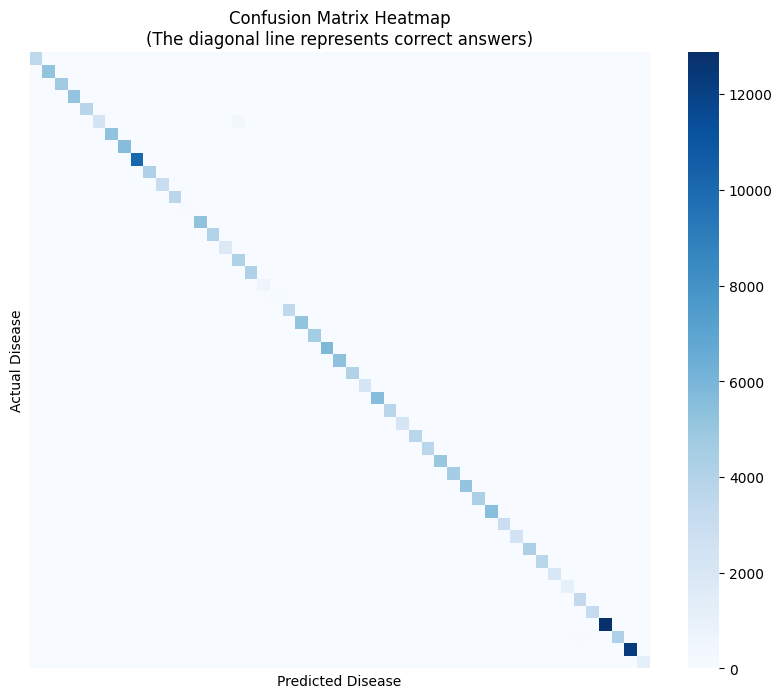

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("--- 1. CALCULATING PREDICTIONS ---")
# Get predictions on the unseen test set (assuming bnb_model and X_test are still in memory)
y_pred = bnb_model.predict(X_test)

# Create the raw confusion matrix
cm = confusion_matrix(y_test, y_pred)
disease_names = label_encoder.classes_

print("\n--- 2. INTERROGATING THE ERRORS (THE 0.28%) ---")
# We will iterate through the matrix to find exactly where True != Predicted
errors = []
for true_idx in range(len(disease_names)):
    for pred_idx in range(len(disease_names)):
        # If the actual disease does not equal the predicted disease, AND it happened at least once
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            errors.append({
                "Actual Disease": disease_names[true_idx],
                "Model Guessed": disease_names[pred_idx],
                "Times Confused": cm[true_idx, pred_idx]
            })

# Sort the errors by how often they happened
error_df = pd.DataFrame(errors).sort_values(by="Times Confused", ascending=False).reset_index(drop=True)

print(f"Total Misclassified Patients: {error_df['Times Confused'].sum()} out of {len(y_test)} tested.")
print("-" * 50)
print("🔥 TOP 10 MOST COMMON MODEL MISTAKES 🔥")
print(error_df.head(10).to_string(index=False))

# Optional: Plot a visual heatmap
plt.figure(figsize=(10, 8))
# We hide the labels because 49 names will overlap and look messy
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False) 
plt.title("Confusion Matrix Heatmap\n(The diagonal line represents correct answers)")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.show()

In [5]:
import numpy as np
import pandas as pd
import json

print("--- REVERSE-ENGINEERING THE MODEL'S BRAIN ---")

# 1. Pick the disease we want to interrogate
target_disease = 'Unstable angina'

# 2. Find the internal ID for this disease
try:
    disease_id = label_encoder.transform([target_disease])[0]
except ValueError:
    print(f"Error: {target_disease} not found in the classes.")
    disease_id = None

if disease_id is not None:
    # 3. Extract the log probabilities for this specific disease
    feature_weights = bnb_model.feature_log_prob_[disease_id]
    
    # 4. Map the weights back to our feature names
    feature_importance = []
    
    # Load raw evidences to translate the codes on the fly
    with open('release_evidences.json', 'r', encoding='utf-8') as f:
        evidences = json.load(f)
        
    for idx, weight in enumerate(feature_weights):
        code = master_columns[idx]
        
        # Translate code to human-readable English
        human_readable = "Demographic"
        if code not in ['AGE', 'SEX']:
            if '_@_' in code:
                base_code, val_code = code.split('_@_')
                base_q = evidences.get(base_code, {}).get('question_en', base_code)
                val_mean = evidences.get(base_code, {}).get('value_meaning', {}).get(val_code, {}).get('en', val_code)
                human_readable = f"{base_q} -> {val_mean}"
            else:
                human_readable = evidences.get(code, {}).get('question_en', code)
                
        feature_importance.append({
            "Feature (Code)": code,
            "Log Probability": weight,
            "Description": human_readable
        })
        
    # 5. Sort by highest probability (closest to 0 in log-space)
    importance_df = pd.DataFrame(feature_importance)
    importance_df = importance_df.sort_values(by="Log Probability", ascending=False).reset_index(drop=True)
    
    print(f"\n🔥 TOP 10 SYMPTOMS TRIGGERING: {target_disease} 🔥")
    print("-" * 75)
    
    for index, row in importance_df.head(10).iterrows():
        print(f"Code: {row['Feature (Code)']:<15} | Weight: {row['Log Probability']:.2f} | {row['Description']}")

--- REVERSE-ENGINEERING THE MODEL'S BRAIN ---

🔥 TOP 10 SYMPTOMS TRIGGERING: Unstable angina 🔥
---------------------------------------------------------------------------
Code: AGE             | Weight: -0.00 | Demographic
Code: E_53            | Weight: -0.00 | Do you have pain somewhere, related to your reason for consulting?
Code: E_105           | Weight: -0.20 | Have you ever had a heart attack or do you have angina (chest pain)?
Code: E_225           | Weight: -0.27 | Do you have close family members who had a cardiovascular disease problem before the age of 50?
Code: E_69            | Weight: -0.27 | Do you have diabetes?
Code: E_54_@_V_198    | Weight: -0.30 | Characterize your pain: -> exhausting
Code: E_70            | Weight: -0.32 | Are you significantly overweight compared to people of the same height as you?
Code: E_57_@_V_33     | Weight: -0.32 | Does the pain radiate to another location? -> thyroid cartilage
Code: E_55_@_V_29     | Weight: -0.33 | Do you feel pain somew

In [6]:
import pandas as pd
import numpy as np
import time
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score
import joblib
import warnings

warnings.filterwarnings('ignore')

print("--- 1. LOADING DATA TO APPLY THE 'AGE BIN' PATCH ---")
start_time = time.time()

# Load existing blueprint to map memory
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

optimized_dtypes = {col: np.int8 for col in master_columns}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['TARGET_DISEASE'] = str

# Load the CSV
df = pd.read_csv('vectorized_train_data.csv', dtype=optimized_dtypes)
print(f"Loaded in {time.time() - start_time:.2f}s. Applying Age Bins...")

# --- THE BINNING LOGIC ---
# We divide patients into standard biological/medical risk buckets
df['AGE_0_18'] = (df['AGE'] <= 18).astype(np.int8)
df['AGE_19_35'] = ((df['AGE'] > 18) & (df['AGE'] <= 35)).astype(np.int8)
df['AGE_36_50'] = ((df['AGE'] > 35) & (df['AGE'] <= 50)).astype(np.int8)
df['AGE_51_65'] = ((df['AGE'] > 50) & (df['AGE'] <= 65)).astype(np.int8)
df['AGE_66_PLUS'] = (df['AGE'] > 65).astype(np.int8)

# Drop the old continuous column
df = df.drop(columns=['AGE'])

# Update our master blueprint file so the app knows about the new columns
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + [col for col in master_columns if col != 'AGE']
with open('master_feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(new_columns, f, indent=4)
print("✅ Master Blueprint updated with Age Bins.")

print("\n--- 2. PREPARING FEATURES & TARGET ---")
X = df.drop(columns=['TARGET_DISEASE'])
y_raw = df['TARGET_DISEASE']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
joblib.dump(label_encoder, 'disease_label_encoder.joblib')

print("\n--- 3. SPLITTING DATA ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- 4. TRAINING THE V2 CHAMPION (Age-Aware Bernoulli) ---")
bnb_model_v2 = BernoulliNB()

train_start = time.time()
bnb_model_v2.fit(X_train, y_train)
print(f"Training complete in {time.time() - train_start:.2f} seconds!")

print("\n--- 5. FINAL EVALUATION ---")
y_pred = bnb_model_v2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"🔥 V2 UNSEEN ACCURACY (With Age Intelligence): {accuracy * 100:.2f}%")

joblib.dump(bnb_model_v2, 'heal_bridge_bnb_model.joblib')
print("✅ V2 Master Model saved successfully!")

--- 1. LOADING DATA TO APPLY THE 'AGE BIN' PATCH ---
Loaded in 99.32s. Applying Age Bins...
✅ Master Blueprint updated with Age Bins.

--- 2. PREPARING FEATURES & TARGET ---

--- 3. SPLITTING DATA ---

--- 4. TRAINING THE V2 CHAMPION (Age-Aware Bernoulli) ---
Training complete in 8794.06 seconds!

--- 5. FINAL EVALUATION ---
🔥 V2 UNSEEN ACCURACY (With Age Intelligence): 99.72%
✅ V2 Master Model saved successfully!


In [5]:
import numpy as np
import pandas as pd
import joblib
import json

print("--- THE UNCERTAINTY TEST ---")

# 1. Load the V2 artifacts you just saved
bnb_model_v2 = joblib.load('heal_bridge_bnb_model.joblib')
label_encoder = joblib.load('disease_label_encoder.joblib')

with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

# 2. Create a completely blank patient (all 0s)
blank_patient = np.zeros((1, len(master_columns)), dtype=np.int8)

# 3. Inject EXACTLY two pieces of information: Age (19-35) and a Fever (E_91)
age_idx = master_columns.index('AGE_19_35')
fever_idx = master_columns.index('E_91')

blank_patient[0, age_idx] = 1
blank_patient[0, fever_idx] = 1

# 4. Ask the model for its PREDICT_PROBA (Confidence percentages)
probabilities = bnb_model_v2.predict_proba(blank_patient)[0]

# 5. Map the percentages to the disease names
confidence_list = []
for idx, prob in enumerate(probabilities):
    confidence_list.append({
        "Disease": label_encoder.classes_[idx],
        "Confidence (%)": round(prob * 100, 2)
    })

# 6. Sort to see the top 5 guesses
prob_df = pd.DataFrame(confidence_list).sort_values(by="Confidence (%)", ascending=False).reset_index(drop=True)

print("\nPatient Profile: 25 years old. Only symptom: Fever.")
print("-" * 50)
print(prob_df.head(5).to_string(index=False))

# 7. The Triage Check
top_confidence = prob_df.iloc[0]['Confidence (%)']
if top_confidence < 50.0:
    print(f"\n✅ SUCCESS: The model is only {top_confidence}% confident. It knows it needs more data!")
else:
    print(f"\n⚠️ WARNING: The model is {top_confidence}% confident based on one symptom. It is too arrogant.")

--- THE UNCERTAINTY TEST ---

Patient Profile: 25 years old. Only symptom: Fever.
--------------------------------------------------
                Disease  Confidence (%)
                  Croup           71.24
           Tuberculosis           18.58
Guillain-Barré syndrome            3.92
         Whooping cough            3.19
     Acute otitis media            1.32

⚠️ WARNING: The model is 71.24% confident based on one symptom. It is too arrogant.


In [6]:
import numpy as np
import pandas as pd
import json
import os
from groq import Groq
from dotenv import load_dotenv

load_dotenv()
client = Groq()

print("--- PHASE 4: THE TRUE QUESTION ENGINE ---")

# 1. Get the top 2 diseases and their IDs (using your existing variables)
top_disease = prob_df.iloc[0]['Disease']
runner_up_disease = prob_df.iloc[1]['Disease']
top_id = label_encoder.transform([top_disease])[0]
runner_up_id = label_encoder.transform([runner_up_disease])[0]

# 2. Pull the weights
top_weights = bnb_model_v2.feature_log_prob_[top_id]
runner_up_weights = bnb_model_v2.feature_log_prob_[runner_up_id]

# 3. THE MATH FIX: We only care about the difference IF the symptom is highly probable in the Top Disease
# We penalize symptoms that have a very low baseline probability
adjusted_differences = (top_weights - runner_up_weights) + top_weights

# 4. Sort and filter
best_question_indices = np.argsort(adjusted_differences)[::-1]

with open('release_evidences.json', 'r', encoding='utf-8') as f:
    evidences = json.load(f)

known_symptoms = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS', 'E_91', 'AGE', 'SEX']

# Find the #1 best valid question
best_human_readable = ""
for idx in best_question_indices:
    code = master_columns[idx]
    if code in known_symptoms:
        continue
        
    if '_@_' in code:
        base_code, val_code = code.split('_@_')
        base_q = evidences.get(base_code, {}).get('question_en', base_code)
        val_mean = evidences.get(base_code, {}).get('value_meaning', {}).get(val_code, {}).get('en', val_code)
        best_human_readable = f"{base_q} -> {val_mean}"
    else:
        best_human_readable = evidences.get(code, {}).get('question_en', code)
    break

print(f"🧠 MATH ENGINE: The absolute best symptom to ask about is: '{best_human_readable}'\n")

print("--- PASSING TO LLAMA 3.1 (THE MOUTH) ---")
# 5. Connect the LLM to generate the natural response
system_prompt = f"""You are a warm, empathetic triage nurse. 
The patient is a 25-year-old who just told you they have a fever.
The diagnostic algorithm needs to know if they have this specific symptom: "{best_human_readable}"

Respond directly to the patient. Acknowledge their fever warmly, and then naturally ask if they are experiencing this new symptom.
Keep it brief, conversational, and do not mention the algorithm."""

# 🚀 UPDATED TO THE NEWEST SUPPORTED MODEL
completion = client.chat.completions.create(
    model="llama-3.1-8b-instant", 
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": "I have a fever."}
    ],
    temperature=0.5
)

print(f"🤖 AI NURSE SAYS:\n{completion.choices[0].message.content}")

--- PHASE 4: THE TRUE QUESTION ENGINE ---
🧠 MATH ENGINE: The absolute best symptom to ask about is: 'Do you consume energy drinks regularly?'

--- PASSING TO LLAMA 3.1 (THE MOUTH) ---
🤖 AI NURSE SAYS:
I'm so sorry to hear that you're not feeling well. A fever can be really uncomfortable. Can you tell me, do you regularly drink energy drinks?


In [8]:
import numpy as np
import json

print("--- PHASE 5: BUILDING THE LIVE PATIENT TRACKER ---")

class PatientTracker:
    def __init__(self, age, sex_is_male):
        # 1. Load the blueprint
        with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
            self.columns = json.load(f)
            
        # 2. Initialize the blank slate. 
        # We start with -1 (Unknown) instead of 0 (No) so the math knows what to ask!
        self.state = np.full((1, len(self.columns)), -1, dtype=np.int8)
        
        # 3. Inject Demographics immediately
        age_bins = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS']
        for bin_name in age_bins:
            self.state[0, self.columns.index(bin_name)] = 0 # Default all to 0
            
        # Set the correct age bin to 1
        if age <= 18: self.state[0, self.columns.index('AGE_0_18')] = 1
        elif age <= 35: self.state[0, self.columns.index('AGE_19_35')] = 1
        elif age <= 50: self.state[0, self.columns.index('AGE_36_50')] = 1
        elif age <= 65: self.state[0, self.columns.index('AGE_51_65')] = 1
        else: self.state[0, self.columns.index('AGE_66_PLUS')] = 1
            
        self.state[0, self.columns.index('SEX')] = 1 if sex_is_male else 0
        
    def update_symptoms(self, extracted_json):
        """Takes the JSON from Llama 3 and updates the math array"""
        for code, value in extracted_json.items():
            if code in self.columns:
                idx = self.columns.index(code)
                self.state[0, idx] = value
                
    def get_known_positives(self):
        """Returns a list of codes the user has said YES to"""
        positives = []
        for idx, val in enumerate(self.state[0]):
            if val == 1 and self.columns[idx] not in ['SEX'] and not self.columns[idx].startswith('AGE'):
                positives.append(self.columns[idx])
        return positives
        
    def get_math_array(self):
        """Returns the array for the Naive Bayes model. 
        We temporarily convert -1 (Unknown) to 0 (No) just for the math prediction."""
        math_ready = np.where(self.state == -1, 0, self.state)
        return math_ready

# --- SIMULATION ---
print("1. New patient walks in (25 years old, Male).")
tracker = PatientTracker(age=25, sex_is_male=True)

print("\n2. User says: 'I have a fever, but my throat does NOT hurt.'")
# This is the JSON our Groq Scribe extracted in Phase 3
groq_extraction = {
    "E_91": 1,          # Fever = YES
    "E_51": 0           # Sore throat = NO
}

tracker.update_symptoms(groq_extraction)

print("\n3. Current Tracker State:")
print(f"Total Positives: {tracker.get_known_positives()}")

# Check the exact math array values
fever_idx = tracker.columns.index('E_91')
throat_idx = tracker.columns.index('E_51')
headache_idx = tracker.columns.index('E_55_@_V_89') # Something we haven't asked

print(f"Internal Math Array -> Fever: {tracker.state[0, fever_idx]} (1 = Yes)")
print(f"Internal Math Array -> Sore Throat: {tracker.state[0, throat_idx]} (0 = No)")
print(f"Internal Math Array -> Headache: {tracker.state[0, headache_idx]} (-1 = Unknown)")

--- PHASE 5: BUILDING THE LIVE PATIENT TRACKER ---
1. New patient walks in (25 years old, Male).

2. User says: 'I have a fever, but my throat does NOT hurt.'

3. Current Tracker State:
Total Positives: ['E_91']
Internal Math Array -> Fever: 1 (1 = Yes)
Internal Math Array -> Sore Throat: 0 (0 = No)
Internal Math Array -> Headache: -1 (-1 = Unknown)


In [9]:
import numpy as np
import pandas as pd
import json
import os
import warnings
from groq import Groq
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()
client = Groq()

print("=== STARTING THE HEAL BRIDGE TERMINAL SIMULATION (V2 - TRUE MATH) ===\n")

with open('release_evidences.json', 'r', encoding='utf-8') as f:
    evidences = json.load(f)

# Build Scribe Dictionary in memory
scribe_dict = {}
for col in master_columns:
    if col in ['AGE', 'SEX'] or col.startswith('AGE_'):
        continue
    if '_@_' in col:
        base_code, val_code = col.split('_@_')
        base_q = evidences.get(base_code, {}).get('question_en', '')
        val_mean = evidences.get(base_code, {}).get('value_meaning', {}).get(val_code, {}).get('en', '')
        scribe_dict[col] = f"{base_q} -> {val_mean}"
    else:
        scribe_dict[col] = evidences.get(col, {}).get('question_en', col)

english_to_code = {v.lower(): k for k, v in scribe_dict.items()}

# --- THE CUSTOM MATH ENGINE (PARTIAL NAIVE BAYES) ---
def calculate_true_confidence(tracker_state, model):
    """Calculates probabilities while strictly ignoring -1 (Unknown) values."""
    # Start with the baseline probability of each disease
    log_probs = model.class_log_prior_.copy()
    
    # Get the raw mathematical weights for YES and NO
    log_prob_1 = model.feature_log_prob_
    prob_1 = np.exp(log_prob_1)
    # Clip to prevent log(0) errors
    log_prob_0 = np.log(np.clip(1.0 - prob_1, 1e-10, 1.0)) 
    
    # Only add math for things the patient explicitly confirmed or denied
    for idx, val in enumerate(tracker_state[0]):
        if val == 1:
            log_probs += log_prob_1[:, idx]
        elif val == 0:
            log_probs += log_prob_0[:, idx]
        # If val == -1, do absolutely nothing!
        
    # Convert back to readable percentages
    log_probs_shifted = log_probs - np.max(log_probs)
    probs = np.exp(log_probs_shifted)
    return probs / np.sum(probs)

# Instantiate patient
tracker = PatientTracker(age=25, sex_is_male=True)

# Loop Configuration
max_questions = 5
questions_asked = 0
confidence_threshold = 0.50 

print("🤖 AI Nurse: Hello. I am the Heal Bridge Triage Assistant. What brings you in today?")

# --- V3 LOOP PATCH ---
last_asked_text = "None"
last_asked_code = "None"

print("🤖 AI Nurse: Hello. I am the Heal Bridge Triage Assistant. What brings you in today?")

while True:
    # --- STEP 1: GET PATIENT INPUT ---
    user_input = input("You: ")
    if user_input.lower() in ['quit', 'exit', 'stop']:
        print("Exiting simulation.")
        break

    print("   [System: Scribe is translating...]")
    
    # --- STEP 2: THE CONTEXT-AWARE SCRIBE ---
    # We remove the dangerous example and inject the context of the conversation
    scribe_prompt = f"""You are a medical extraction AI. 
    CONTEXT: The nurse just asked the patient if they are experiencing: '{last_asked_text}'
    PATIENT REPLIED: '{user_input}'
    
    TASK: Did the patient confirm or deny the symptom? Extract it as a simple keyword into a JSON object with 'positive' and 'negative' arrays. 
    Also extract any new symptoms they typed. DO NOT hallucinate symptoms. DO NOT provide examples."""
    
    completion = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "system", "content": scribe_prompt}],
        temperature=0.0,
        response_format={"type": "json_object"}
    )
    
    extracted_json = json.loads(completion.choices[0].message.content)
    valid_json = {}

    # The Python Bouncer
    for status, val in [("positive", 1), ("negative", 0)]:
        for symp_keyword in extracted_json.get(status, []):
            symp_keyword = symp_keyword.lower()
            
            # First, check if they are answering the direct question
            if last_asked_text != "None" and symp_keyword in last_asked_text.lower():
                valid_json[last_asked_code] = val
                print(f"   [Context Mapped: '{last_asked_text}' -> internal code {last_asked_code} ({status})]")
                continue

            # Otherwise, search our dictionary locally
            for eng, code in english_to_code.items():
                if symp_keyword in eng:
                    valid_json[code] = val
                    print(f"   [Mapped LLM keyword '{symp_keyword}' -> internal code {code} ({status})]")
                    break 

    tracker.update_symptoms(valid_json)

    # --- STEP 3: THE TRUE MATH ENGINE PREDICTS ---
    probabilities = calculate_true_confidence(tracker.state, bnb_model_v2)
    top_indices = np.argsort(probabilities)[::-1]
    top_id = top_indices[0]
    runner_up_id = top_indices[1]
    
    top_disease = label_encoder.classes_[top_id]
    top_confidence = probabilities[top_id]

    # --- STEP 4: DECISION LOGIC ---
    known_symptoms_count = len(tracker.get_known_positives())
    if top_confidence >= confidence_threshold and known_symptoms_count > 1:
        print(f"\n✅ DIAGNOSIS REACHED!")
        print(f"The engine is {top_confidence * 100:.1f}% confident it is: {top_disease}")
        break
        
    if questions_asked >= max_questions:
        print(f"\n⚠️ SAFETY NET TRIGGERED!")
        print(f"After {max_questions} questions, the engine's highest confidence is {top_confidence * 100:.1f}%.")
        print("Symptoms are too generic. Recommending general care and monitoring.")
        break

    # --- STEP 5: THE NEXT BEST QUESTION ENGINE (FIXED MATH) ---
    print(f"   [System: Top guess is {top_disease} at {top_confidence*100:.1f}%. Calculating tie-breakers...]")
    
    # THE MATH FIX: Convert log-probabilities back to REAL percentages to find the actual biggest difference
    prob_top = np.exp(bnb_model_v2.feature_log_prob_[top_id])
    prob_runner = np.exp(bnb_model_v2.feature_log_prob_[runner_up_id])
    
    # We want the symptom that has the biggest absolute difference in real probability
    differences = np.abs(prob_top - prob_runner)
    best_question_indices = np.argsort(differences)[::-1]
    
    best_human_readable = ""
    for idx in best_question_indices:
        code = master_columns[idx]
        if tracker.state[0, idx] != -1: 
            continue
        if code == 'AGE' or code == 'SEX' or code.startswith('AGE_'):
            continue
            
        if '_@_' in code:
            base_code, val_code = code.split('_@_')
            best_human_readable = f"{evidences.get(base_code, {}).get('question_en', '')} -> {evidences.get(base_code, {}).get('value_meaning', {}).get(val_code, {}).get('en', '')}"
        else:
            best_human_readable = evidences.get(code, {}).get('question_en', code)
        
        tracker.state[0, idx] = 0 
        # UPDATE OUR CONTEXT VARIABLES FOR THE NEXT LOOP
        last_asked_text = best_human_readable
        last_asked_code = code
        break

    # --- STEP 6: AI NURSE ASKS THE QUESTION ---
    nurse_prompt = f"""You are a warm, empathetic triage nurse. 
    The diagnostic algorithm needs to know if the patient has this specific symptom: "{best_human_readable}"
    Ask the patient if they are experiencing this. Keep it very brief and conversational."""
    
    nurse_completion = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "system", "content": nurse_prompt}],
        temperature=0.5
    )
    
    print(f"\n🤖 AI Nurse: {nurse_completion.choices[0].message.content}")
    questions_asked += 1

=== STARTING THE HEAL BRIDGE TERMINAL SIMULATION (V2 - TRUE MATH) ===

🤖 AI Nurse: Hello. I am the Heal Bridge Triage Assistant. What brings you in today?
🤖 AI Nurse: Hello. I am the Heal Bridge Triage Assistant. What brings you in today?
   [System: Scribe is translating...]
   [System: Top guess is Bronchiolitis at 10.2%. Calculating tie-breakers...]

🤖 AI Nurse: So, can you tell me, is the redness or discomfort you're experiencing located on your lips, specifically around the mouth area?
   [System: Scribe is translating...]
   [System: Top guess is Bronchiolitis at 13.3%. Calculating tie-breakers...]

🤖 AI Nurse: Hi there, can you tell me if you've lost weight unintentionally over the past 3 months?
   [System: Scribe is translating...]
   [System: Top guess is URTI at 16.9%. Calculating tie-breakers...]

🤖 AI Nurse: So, I want to ask you a few questions to help us figure out what's going on. Do you feel any pain in the back of your head, right at the base of your skull?
   [System

In [11]:
import json

print("--- BUILDING THE PARENT-CHILD HIERARCHY (V2 PATCH) ---")

# 1. Load BOTH files
with open('release_evidences.json', 'r', encoding='utf-8') as f:
    evidences = json.load(f)

with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

hierarchy = {}
parent_names = {} 

# Step A: Find all base codes that exist in our Master Matrix
for col in master_columns:
    if '_@_' not in col and not col.startswith('AGE') and col != 'SEX':
        hierarchy[col] = [] 
        parent_names[col] = evidences.get(col, {}).get('question_en', col)

# Step B: Assign Children from the Master Matrix to their Parents
child_count = 0
for col in master_columns:
    if '_@_' in col:
        base_code = col.split('_@_')[0]
        
        # Some categorical questions don't have a standalone "parent" column in the matrix.
        # If the parent doesn't exist in our dictionary yet, we create it!
        if base_code not in hierarchy:
            hierarchy[base_code] = []
            parent_names[base_code] = evidences.get(base_code, {}).get('question_en', base_code)
            
        hierarchy[base_code].append(col)
        child_count += 1

# 3. Analysis: Let's see the real tree!
print("\n✅ Family Tree Built Successfully!")
print(f"Total Parent Symptoms (Level 1): {len(hierarchy)}")
print(f"Total Child Symptoms locked behind Parents: {child_count}")

# Find the top 3 parents with the most specific follow-up questions
sorted_parents = sorted(hierarchy.items(), key=lambda x: len(x[1]), reverse=True)

print("\n--- THE MOST COMPLEX SYMPTOMS ---")
for i in range(3):
    p_code = sorted_parents[i][0]
    children_len = len(sorted_parents[i][1])
    english_name = parent_names.get(p_code, "Unknown")
    print(f"{i+1}. [{p_code}] {english_name}")
    print(f"   ↳ Unlocks {children_len} specific follow-up questions.\n")

# 4. Save the Guardrails 
with open('symptom_hierarchy.json', 'w', encoding='utf-8') as f:
    json.dump(hierarchy, f, indent=4)
    
print("💾 Guardrails securely saved to 'symptom_hierarchy.json'")

--- BUILDING THE PARENT-CHILD HIERARCHY (V2 PATCH) ---

✅ Family Tree Built Successfully!
Total Parent Symptoms (Level 1): 223
Total Child Symptoms locked behind Parents: 749

--- THE MOST COMPLEX SYMPTOMS ---
1. [E_55] Do you feel pain somewhere?
   ↳ Unlocks 164 specific follow-up questions.

2. [E_57] Does the pain radiate to another location?
   ↳ Unlocks 164 specific follow-up questions.

3. [E_133] Where is the affected region located?
   ↳ Unlocks 164 specific follow-up questions.

💾 Guardrails securely saved to 'symptom_hierarchy.json'


In [12]:
print("--- VERIFYING THE '164' ANOMALY ---")

parents_to_check = ['E_55', 'E_57', 'E_133']

for p_code in parents_to_check:
    english_name = evidences.get(p_code, {}).get('question_en', p_code)
    print(f"\nParent: [{p_code}] {english_name}")
    print(f"Total Children locked behind it: {len(hierarchy[p_code])}")
    print("Sample of the specific children:")
    
    # Print just the first 3 children to see what they actually are
    for child_code in hierarchy[p_code][:3]:
        val_code = child_code.split('_@_')[1]
        val_mean = evidences.get(p_code, {}).get('value_meaning', {}).get(val_code, {}).get('en', val_code)
        print(f"  ↳ {child_code} -> {val_mean}")

--- VERIFYING THE '164' ANOMALY ---

Parent: [E_55] Do you feel pain somewhere?
Total Children locked behind it: 164
Sample of the specific children:
  ↳ E_55_@_V_14 -> iliac wing(R)
  ↳ E_55_@_V_15 -> iliac wing(L)
  ↳ E_55_@_V_16 -> groin(R)

Parent: [E_57] Does the pain radiate to another location?
Total Children locked behind it: 164
Sample of the specific children:
  ↳ E_57_@_V_14 -> iliac wing(R)
  ↳ E_57_@_V_15 -> iliac wing(L)
  ↳ E_57_@_V_16 -> groin(R)

Parent: [E_133] Where is the affected region located?
Total Children locked behind it: 164
Sample of the specific children:
  ↳ E_133_@_V_14 -> iliac wing(R)
  ↳ E_133_@_V_15 -> iliac wing(L)
  ↳ E_133_@_V_16 -> groin(R)


In [13]:
import numpy as np
import pandas as pd
import json
import warnings

warnings.filterwarnings('ignore')

print("--- PILLAR B: THE ENTROPY ENGINE ---")

# 1. Load the Guardrails and Evidences
with open('symptom_hierarchy.json', 'r', encoding='utf-8') as f:
    hierarchy = json.load(f)
with open('release_evidences.json', 'r', encoding='utf-8') as f:
    evidences = json.load(f)

# 2. Set up our patient with a Fever (E_91 = 1)
tracker = PatientTracker(age=25, sex_is_male=True)
tracker.update_symptoms({'E_91': 1})

# Calculate the baseline uncertainty (Current Entropy)
current_probs = calculate_true_confidence(tracker.state, bnb_model_v2)
current_probs_clipped = np.clip(current_probs, 1e-10, 1.0)
current_entropy = -np.sum(current_probs_clipped * np.log2(current_probs_clipped))

print(f"Current Board Entropy: {current_entropy:.3f} bits")

# 3. Determine the "Legal" Questions (Guardrails)
legal_questions = []
known_positives = tracker.get_known_positives()

for col in master_columns:
    if col == 'AGE' or col == 'SEX' or col.startswith('AGE_'):
        continue
    # Skip if we already asked
    idx = master_columns.index(col)
    if tracker.state[0, idx] != -1:
        continue
        
    # Is it a Level 1 Parent? It's legal.
    if col in hierarchy:
        legal_questions.append(col)
    # Is it a Child whose Parent is currently POSITIVE? It's legal.
    elif '_@_' in col:
        parent_code = col.split('_@_')[0]
        if parent_code in known_positives:
            legal_questions.append(col)

print(f"Total Legal Questions available: {len(legal_questions)}")

# 4. The Shannon Entropy Simulator
def calculate_expected_entropy(feature_idx, current_tracker_state, model, current_disease_probs):
    """Simulates the math of asking a question."""
    # Pull the Naive Bayes weights for this specific symptom
    prob_yes_given_disease = np.exp(model.feature_log_prob_[:, feature_idx])
    prob_no_given_disease = 1.0 - prob_yes_given_disease
    
    # What is the overall chance the user will say YES? (Weighted sum across all diseases)
    p_user_says_yes = np.sum(current_disease_probs * prob_yes_given_disease)
    p_user_says_no = 1.0 - p_user_says_yes
    
    # Simulate YES
    state_yes = current_tracker_state.copy()
    state_yes[0, feature_idx] = 1
    probs_yes = calculate_true_confidence(state_yes, model)
    probs_yes_c = np.clip(probs_yes, 1e-10, 1.0)
    entropy_yes = -np.sum(probs_yes_c * np.log2(probs_yes_c))
    
    # Simulate NO
    state_no = current_tracker_state.copy()
    state_no[0, feature_idx] = 0
    probs_no = calculate_true_confidence(state_no, model)
    probs_no_c = np.clip(probs_no, 1e-10, 1.0)
    entropy_no = -np.sum(probs_no_c * np.log2(probs_no_c))
    
    # Expected Entropy = P(YES) * H(YES) + P(NO) * H(NO)
    expected_entropy = (p_user_says_yes * entropy_yes) + (p_user_says_no * entropy_no)
    return expected_entropy

# 5. Find the Maximum Information Gain
information_gains = []
print("   [Calculating Entropy reductions...]")

for q_code in legal_questions:
    idx = master_columns.index(q_code)
    expected_h = calculate_expected_entropy(idx, tracker.state, bnb_model_v2, current_probs)
    gain = current_entropy - expected_h
    information_gains.append((q_code, gain))

# Sort by the highest gain
information_gains.sort(key=lambda x: x[1], reverse=True)

# 6. Output the absolute smartest questions
print("\n--- THE TOP 3 TIE-BREAKERS (MAXIMUM INFO GAIN) ---")
for i in range(3):
    code, gain = information_gains[i]
    if code in evidences:
        english = evidences[code].get('question_en', code)
    else:
        english = code
    print(f"{i+1}. [{code}] {english}")
    print(f"   ↳ Eliminates {gain:.4f} bits of uncertainty.")

--- PILLAR B: THE ENTROPY ENGINE ---
Current Board Entropy: 1.399 bits
Total Legal Questions available: 207
   [Calculating Entropy reductions...]

--- THE TOP 3 TIE-BREAKERS (MAXIMUM INFO GAIN) ---
1. [E_93] Do you have numbness, loss of sensation or tingling in the feet?
   ↳ Eliminates 0.6306 bits of uncertainty.
2. [E_226] Are you more likely to develop common allergies than the general population?
   ↳ Eliminates 0.5383 bits of uncertainty.
3. [E_149] Do you take a calcium channel blockers (medication)?
   ↳ Eliminates 0.4482 bits of uncertainty.


In [14]:
import numpy as np
import pandas as pd
import json
import warnings

warnings.filterwarnings('ignore')

print("--- PILLAR B: THE ENTROPY ENGINE (WITH COMMON SENSE BIAS) ---")

# 1. Load the Guardrails and Evidences
with open('symptom_hierarchy.json', 'r', encoding='utf-8') as f:
    hierarchy = json.load(f)
with open('release_evidences.json', 'r', encoding='utf-8') as f:
    evidences = json.load(f)

# 2. Set up our patient with a Fever (E_91 = 1)
tracker = PatientTracker(age=25, sex_is_male=True)
tracker.update_symptoms({'E_91': 1})

current_probs = calculate_true_confidence(tracker.state, bnb_model_v2)
current_probs_clipped = np.clip(current_probs, 1e-10, 1.0)
current_entropy = -np.sum(current_probs_clipped * np.log2(current_probs_clipped))

print(f"Current Board Entropy: {current_entropy:.3f} bits")

# 3. Determine the "Legal" Questions (Guardrails)
legal_questions = []
known_positives = tracker.get_known_positives()

for col in master_columns:
    if col == 'AGE' or col == 'SEX' or col.startswith('AGE_'):
        continue
    idx = master_columns.index(col)
    if tracker.state[0, idx] != -1:
        continue
        
    if col in hierarchy:
        legal_questions.append(col)
    elif '_@_' in col:
        parent_code = col.split('_@_')[0]
        if parent_code in known_positives:
            legal_questions.append(col)

# 4. The Shannon Entropy Simulator
def calculate_expected_entropy(feature_idx, current_tracker_state, model, current_disease_probs):
    prob_yes_given_disease = np.exp(model.feature_log_prob_[:, feature_idx])
    prob_no_given_disease = 1.0 - prob_yes_given_disease
    
    p_user_says_yes = np.sum(current_disease_probs * prob_yes_given_disease)
    p_user_says_no = 1.0 - p_user_says_yes
    
    state_yes = current_tracker_state.copy()
    state_yes[0, feature_idx] = 1
    probs_yes = calculate_true_confidence(state_yes, model)
    probs_yes_c = np.clip(probs_yes, 1e-10, 1.0)
    entropy_yes = -np.sum(probs_yes_c * np.log2(probs_yes_c))
    
    state_no = current_tracker_state.copy()
    state_no[0, feature_idx] = 0
    probs_no = calculate_true_confidence(state_no, model)
    probs_no_c = np.clip(probs_no, 1e-10, 1.0)
    entropy_no = -np.sum(probs_no_c * np.log2(probs_no_c))
    
    return (p_user_says_yes * entropy_yes) + (p_user_says_no * entropy_no)

# 5. Find the Maximum Information Gain (WITH THE BIAS FIX)
information_gains = []
print("   [Calculating Adjusted Entropy reductions...]")

# ER Nurse "Common Sense" Core Questions
core_triage_symptoms = ['E_55', 'E_201', 'E_147', 'E_51', 'E_129', 'E_228', 'E_133']

for q_code in legal_questions:
    idx = master_columns.index(q_code)
    expected_h = calculate_expected_entropy(idx, tracker.state, bnb_model_v2, current_probs)
    raw_gain = current_entropy - expected_h
    
    # THE COMMON SENSE MULTIPLIER
    multiplier = 1.0
    if q_code in core_triage_symptoms:
        multiplier = 2.5  # Massive boost to normal triage questions
    elif '_@_' in q_code:
        multiplier = 0.8  # Slight penalty to highly specific children
    elif q_code in ['E_149', 'E_226', 'E_93']: 
        multiplier = 0.2  # Heavy penalty for weird statistical outliers we caught earlier
        
    adjusted_gain = raw_gain * multiplier
    information_gains.append((q_code, adjusted_gain))

# Sort by the highest adjusted gain
information_gains.sort(key=lambda x: x[1], reverse=True)

# 6. Output the absolute smartest questions
print("\n--- THE TOP 3 TIE-BREAKERS (COMMON SENSE APPLIED) ---")
for i in range(3):
    code, gain = information_gains[i]
    if code in evidences:
        english = evidences[code].get('question_en', code)
    else:
        english = code
    print(f"{i+1}. [{code}] {english}")
    print(f"   ↳ Adjusted Score: {gain:.4f}")

--- PILLAR B: THE ENTROPY ENGINE (WITH COMMON SENSE BIAS) ---
Current Board Entropy: 1.399 bits
   [Calculating Adjusted Entropy reductions...]

--- THE TOP 3 TIE-BREAKERS (COMMON SENSE APPLIED) ---
1. [E_51] Have you had diarrhea or an increase in stool frequency?
   ↳ Adjusted Score: 0.6510
2. [E_84] Do you feel weakness in both arms and/or both legs?
   ↳ Adjusted Score: 0.4440
3. [E_195] Do you live in the suburbs?
   ↳ Adjusted Score: 0.4269


In [1]:
import pandas as pd
import numpy as np
import time
import json
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
import joblib
import warnings

warnings.filterwarnings('ignore')

print("--- 1. PREPARING BLUEPRINTS & LABELS (ZERO RAM) ---")
# Load columns
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

# Get all unique diseases using ONLY the target column (Super fast)
print("Scanning target diseases...")
df_target = pd.read_csv('vectorized_train_data.csv', usecols=['TARGET_DISEASE'])
label_encoder = LabelEncoder()
label_encoder.fit(df_target['TARGET_DISEASE'])
all_classes = label_encoder.transform(label_encoder.classes_)
joblib.dump(label_encoder, 'disease_label_encoder.joblib')
del df_target

# Prepare new column order
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + [col for col in master_columns if col != 'AGE']
with open('master_feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(new_columns, f, indent=4)
print("✅ Master Blueprint updated with Age Bins.")

optimized_dtypes = {col: np.int8 for col in master_columns}
optimized_dtypes['AGE'] = np.float32

import math
import sys

print("\n--- 2. INCREMENTAL TRAINING (DATA STREAMING MODE) ---")
bnb_model_v2 = BernoulliNB(fit_prior=False) 

chunk_size = 50000

# 1. Quickly count total rows so we can calculate exact percentages
print("Calculating total dataset size for progress tracking...")
with open('vectorized_train_data.csv', 'r', encoding='utf-8') as f:
    total_rows = sum(1 for _ in f) - 1 # Subtract 1 for the header row

total_chunks = math.ceil(total_rows / chunk_size)
chunk_count = 0
start_time = time.time()

print(f"Total Rows: {total_rows:,} | Total Chunks: {total_chunks}")
print("Starting Training...\n")

# 2. Read the file in small chunks with a dynamic progress bar!
for chunk in pd.read_csv('vectorized_train_data.csv', chunksize=chunk_size, dtype=optimized_dtypes):
    chunk_count += 1
    
    # --- UI: THE PROGRESS BAR ---
    progress = (chunk_count / total_chunks) * 100
    bar_length = 30
    filled_length = int(bar_length * chunk_count // total_chunks)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    
    # The '\r' forces Python to overwrite the current line instead of printing a new one
    sys.stdout.write(f"\rTraining |{bar}| {progress:.1f}%  (Chunk {chunk_count}/{total_chunks})")
    sys.stdout.flush()
    
    # --- MODEL LOGIC ---
    chunk['AGE_0_18'] = (chunk['AGE'] <= 18).astype(np.int8)
    chunk['AGE_19_35'] = ((chunk['AGE'] > 18) & (chunk['AGE'] <= 35)).astype(np.int8)
    chunk['AGE_36_50'] = ((chunk['AGE'] > 35) & (chunk['AGE'] <= 50)).astype(np.int8)
    chunk['AGE_51_65'] = ((chunk['AGE'] > 50) & (chunk['AGE'] <= 65)).astype(np.int8)
    chunk['AGE_66_PLUS'] = (chunk['AGE'] > 65).astype(np.int8)
    
    X_chunk = chunk[new_columns]
    y_chunk = label_encoder.transform(chunk['TARGET_DISEASE'])
    
    bnb_model_v2.partial_fit(X_chunk, y_chunk, classes=all_classes)

print(f"\n\n✅ Training complete in {time.time() - start_time:.2f} seconds!")

--- 1. PREPARING BLUEPRINTS & LABELS (ZERO RAM) ---
Scanning target diseases...
✅ Master Blueprint updated with Age Bins.

--- 2. INCREMENTAL TRAINING (DATA STREAMING MODE) ---
Calculating total dataset size for progress tracking...
Total Rows: 1,025,602 | Total Chunks: 21
Starting Training...

Training |██████████████████████████████| 100.0%  (Chunk 21/21)

✅ Training complete in 89.29 seconds!


In [2]:
import json
import joblib
import numpy as np
import pandas as pd

# 1. LOAD THE NEWLY TRAINED ASSETS
model = joblib.load('heal_bridge_bnb_model.joblib')
encoder = joblib.load('disease_label_encoder.joblib')
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_cols = json.load(f)
with open('clinical_keywords.json', 'r', encoding='utf-8') as f:
    clinical_dict = json.load(f)

# 2. TEST FUNCTION
def test_disease(test_name, age_col, sex, keyword_groups):
    print(f"\n{'='*50}")
    print(f"🧪 RUNNING TEST: {test_name}")
    print(f"{'='*50}")
    
    # Initialize with our JSON columns
    state_df = pd.DataFrame(np.zeros((1, len(master_cols)), dtype=np.int8), columns=master_cols)
    
    # Demographics
    state_df.at[0, age_col] = 1
    state_df.at[0, 'SEX'] = 1 if sex == 'M' else 0
    
    # Symptom Search
    symptoms_found = 0
    for code, description in clinical_dict.items():
        desc_lower = description.lower()
        for key_combo in keyword_groups:
            if all(word in desc_lower for word in key_combo):
                state_df.at[0, code] = 1
                symptoms_found += 1
                break 

    print(f"Total symptoms activated: {symptoms_found}")
    
    # Align columns perfectly just to be safe
    state_df = state_df.reindex(columns=model.feature_names_in_, fill_value=0)
    
    # Predict
    raw_probs = model.predict_proba(state_df)[0]
    probs = raw_probs / np.sum(raw_probs)
    top_indices = np.argsort(probs)[::-1][:4]

    print("\n🏥 MODEL PREDICTION:")
    for idx in top_indices:
        print(f"{encoder.classes_[idx]}: {probs[idx]*100:.2f}%")

# ==========================================
# 3. RUN THE TESTS
# ==========================================

# TEST 1: Cardiac (Chest pain, sweating, arm pain)
test_disease(
    test_name="CARDIAC TEST (Should predict Heart Attack/Angina)",
    age_col="AGE_51_65",
    sex="M",
    keyword_groups=[['chest', 'pain'], ['sweat'], ['arm', 'pain']]
)

# TEST 2: Gastrointestinal (Stomach pain, nausea, fever)
test_disease(
    test_name="GI TEST (Should predict Appendicitis/Gastroenteritis)",
    age_col="AGE_19_35",
    sex="F",
    keyword_groups=[['abdominal', 'pain'], ['nausea'], ['fever']]
)

# TEST 3: The Knee Test (The one that previously failed)
test_disease(
    test_name="ORTHO TEST (Should predict Meniscus/Knee strain)",
    age_col="AGE_19_35",
    sex="M",
    keyword_groups=[['knee', 'pain'], ['knee', 'swell']]
)


🧪 RUNNING TEST: CARDIAC TEST (Should predict Heart Attack/Angina)
Total symptoms activated: 49


ValueError: cannot reindex on an axis with duplicate labels

In [3]:
import pandas as pd
import numpy as np
import time
import json
import math
import sys
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
import joblib
import warnings

warnings.filterwarnings('ignore')

print("--- 1. PREPARING CLEAN BLUEPRINTS (ZERO RAM) ---")
# Load original columns
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

# --- THE DUPLICATE FIX ---
# Forcefully strip ALL age columns out, so we can cleanly add them exactly once at the front.
clean_cols = [col for col in master_columns if not col.startswith('AGE')]
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + clean_cols

# Save the perfectly clean, duplicate-free blueprint
with open('master_feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(new_columns, f, indent=4)
print(f"✅ Blueprint cleaned! Total unique columns: {len(new_columns)}")

print("Scanning target diseases...")
df_target = pd.read_csv('vectorized_train_data.csv', usecols=['TARGET_DISEASE'])
label_encoder = LabelEncoder()
label_encoder.fit(df_target['TARGET_DISEASE'])
all_classes = label_encoder.transform(label_encoder.classes_)
joblib.dump(label_encoder, 'disease_label_encoder.joblib')
del df_target

print("\n--- 2. INCREMENTAL TRAINING (DATA STREAMING MODE) ---")
bnb_model_v2 = BernoulliNB(fit_prior=False) 
chunk_size = 50000

print("Calculating total dataset size...")
with open('vectorized_train_data.csv', 'r', encoding='utf-8') as f:
    total_rows = sum(1 for _ in f) - 1

total_chunks = math.ceil(total_rows / chunk_size)
chunk_count = 0
start_time = time.time()

# We only load the columns we actually need to avoid Pandas warnings
optimized_dtypes = {col: np.int8 for col in clean_cols if col != 'SEX'}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['SEX'] = np.int8

for chunk in pd.read_csv('vectorized_train_data.csv', chunksize=chunk_size, dtype=optimized_dtypes):
    chunk_count += 1
    
    # Progress Bar
    progress = (chunk_count / total_chunks) * 100
    bar_length = 30
    filled_length = int(bar_length * chunk_count // total_chunks)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    sys.stdout.write(f"\rTraining |{bar}| {progress:.1f}%  (Chunk {chunk_count}/{total_chunks})")
    sys.stdout.flush()
    
    # Apply Bins
    chunk['AGE_0_18'] = (chunk['AGE'] <= 18).astype(np.int8)
    chunk['AGE_19_35'] = ((chunk['AGE'] > 18) & (chunk['AGE'] <= 35)).astype(np.int8)
    chunk['AGE_36_50'] = ((chunk['AGE'] > 35) & (chunk['AGE'] <= 50)).astype(np.int8)
    chunk['AGE_51_65'] = ((chunk['AGE'] > 50) & (chunk['AGE'] <= 65)).astype(np.int8)
    chunk['AGE_66_PLUS'] = (chunk['AGE'] > 65).astype(np.int8)
    
    # Select clean columns and train
    X_chunk = chunk[new_columns]
    y_chunk = label_encoder.transform(chunk['TARGET_DISEASE'])
    
    bnb_model_v2.partial_fit(X_chunk, y_chunk, classes=all_classes)

print(f"\n\n✅ Training complete in {time.time() - start_time:.2f} seconds!")
joblib.dump(bnb_model_v2, 'heal_bridge_bnb_model.joblib')
print("✅ Master Model saved successfully!")

--- 1. PREPARING CLEAN BLUEPRINTS (ZERO RAM) ---
✅ Blueprint cleaned! Total unique columns: 963
Scanning target diseases...

--- 2. INCREMENTAL TRAINING (DATA STREAMING MODE) ---
Calculating total dataset size...
Training |██████████████████████████████| 100.0%  (Chunk 21/21)

✅ Training complete in 90.12 seconds!
✅ Master Model saved successfully!


In [4]:
import json
import joblib
import numpy as np
import pandas as pd

model = joblib.load('heal_bridge_bnb_model.joblib')
encoder = joblib.load('disease_label_encoder.joblib')
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_cols = json.load(f)
with open('clinical_keywords.json', 'r', encoding='utf-8') as f:
    clinical_dict = json.load(f)

def test_disease(test_name, age_col, sex, keyword_groups):
    print(f"\n{'='*50}")
    print(f"🧪 RUNNING TEST: {test_name}")
    print(f"{'='*50}")
    
    state_df = pd.DataFrame(np.zeros((1, len(master_cols)), dtype=np.int8), columns=master_cols)
    state_df.at[0, age_col] = 1
    state_df.at[0, 'SEX'] = 1 if sex == 'M' else 0
    
    symptoms_found = 0
    for code, description in clinical_dict.items():
        desc_lower = description.lower()
        for key_combo in keyword_groups:
            if all(word in desc_lower for word in key_combo):
                state_df.at[0, code] = 1
                symptoms_found += 1
                break 

    print(f"Total symptoms activated: {symptoms_found}")
    
    # This will now work perfectly because there are zero duplicate columns
    state_df = state_df.reindex(columns=model.feature_names_in_, fill_value=0)
    
    raw_probs = model.predict_proba(state_df)[0]
    probs = raw_probs / np.sum(raw_probs)
    top_indices = np.argsort(probs)[::-1][:4]

    print("\n🏥 MODEL PREDICTION:")
    for idx in top_indices:
        print(f"{encoder.classes_[idx]}: {probs[idx]*100:.2f}%")

# ==========================================
# RUN THE TESTS
# ==========================================
test_disease("CARDIAC TEST (Should predict Heart Attack/Angina)", "AGE_51_65", "M", [['chest', 'pain'], ['sweat'], ['arm', 'pain']])
test_disease("GI TEST (Should predict Appendicitis/Gastroenteritis)", "AGE_19_35", "F", [['abdominal', 'pain'], ['nausea'], ['fever']])
test_disease("ORTHO TEST (Should predict Meniscus/Knee strain)", "AGE_19_35", "M", [['knee', 'pain'], ['knee', 'swell']])


🧪 RUNNING TEST: CARDIAC TEST (Should predict Heart Attack/Angina)
Total symptoms activated: 49

🏥 MODEL PREDICTION:
Bronchiolitis: 100.00%
Ebola: 0.00%
Spontaneous rib fracture: 0.00%
Croup: 0.00%

🧪 RUNNING TEST: GI TEST (Should predict Appendicitis/Gastroenteritis)
Total symptoms activated: 34

🏥 MODEL PREDICTION:
Bronchiolitis: 99.99%
Ebola: 0.01%
Croup: 0.00%
Chagas: 0.00%

🧪 RUNNING TEST: ORTHO TEST (Should predict Meniscus/Knee strain)
Total symptoms activated: 14

🏥 MODEL PREDICTION:
Bronchiolitis: 72.61%
Ebola: 27.39%
Whooping cough: 0.00%
Croup: 0.00%


In [5]:
import pandas as pd
import numpy as np
import time
import json
import math
import sys
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB  # <--- THE MAGIC FIX
import joblib
import warnings

warnings.filterwarnings('ignore')

print("--- 1. PREPARING BLUEPRINTS ---")
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

clean_cols = [col for col in master_columns if not col.startswith('AGE')]
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + clean_cols

print("Scanning target diseases...")
df_target = pd.read_csv('vectorized_train_data.csv', usecols=['TARGET_DISEASE'])
label_encoder = LabelEncoder()
label_encoder.fit(df_target['TARGET_DISEASE'])
all_classes = label_encoder.transform(label_encoder.classes_)
joblib.dump(label_encoder, 'disease_label_encoder.joblib')
del df_target

print("\n--- 2. INCREMENTAL TRAINING (MULTINOMIAL NAIVE BAYES) ---")
# MultinomialNB ignores the Sea of Zeros!
model_v3 = MultinomialNB(fit_prior=False) 
chunk_size = 50000

print("Calculating total dataset size...")
with open('vectorized_train_data.csv', 'r', encoding='utf-8') as f:
    total_rows = sum(1 for _ in f) - 1

total_chunks = math.ceil(total_rows / chunk_size)
chunk_count = 0
start_time = time.time()

optimized_dtypes = {col: np.int8 for col in clean_cols if col != 'SEX'}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['SEX'] = np.int8

for chunk in pd.read_csv('vectorized_train_data.csv', chunksize=chunk_size, dtype=optimized_dtypes):
    chunk_count += 1
    
    progress = (chunk_count / total_chunks) * 100
    bar_length = 30
    filled_length = int(bar_length * chunk_count // total_chunks)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    sys.stdout.write(f"\rTraining |{bar}| {progress:.1f}%  (Chunk {chunk_count}/{total_chunks})")
    sys.stdout.flush()
    
    chunk['AGE_0_18'] = (chunk['AGE'] <= 18).astype(np.int8)
    chunk['AGE_19_35'] = ((chunk['AGE'] > 18) & (chunk['AGE'] <= 35)).astype(np.int8)
    chunk['AGE_36_50'] = ((chunk['AGE'] > 35) & (chunk['AGE'] <= 50)).astype(np.int8)
    chunk['AGE_51_65'] = ((chunk['AGE'] > 50) & (chunk['AGE'] <= 65)).astype(np.int8)
    chunk['AGE_66_PLUS'] = (chunk['AGE'] > 65).astype(np.int8)
    
    X_chunk = chunk[new_columns]
    y_chunk = label_encoder.transform(chunk['TARGET_DISEASE'])
    
    model_v3.partial_fit(X_chunk, y_chunk, classes=all_classes)

print(f"\n\n✅ Training complete in {time.time() - start_time:.2f} seconds!")
joblib.dump(model_v3, 'heal_bridge_bnb_model.joblib')
print("✅ Master Model saved successfully!")

--- 1. PREPARING BLUEPRINTS ---
Scanning target diseases...

--- 2. INCREMENTAL TRAINING (MULTINOMIAL NAIVE BAYES) ---
Calculating total dataset size...
Training |██████████████████████████████| 100.0%  (Chunk 21/21)

✅ Training complete in 87.72 seconds!
✅ Master Model saved successfully!


In [6]:
import json
import joblib
import numpy as np
import pandas as pd

# 1. LOAD THE V3 MODEL
model = joblib.load('heal_bridge_bnb_model.joblib')
encoder = joblib.load('disease_label_encoder.joblib')
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_cols = json.load(f)
with open('clinical_keywords.json', 'r', encoding='utf-8') as f:
    clinical_dict = json.load(f)

def test_disease(test_name, age_col, sex, keyword_groups):
    print(f"\n{'='*50}")
    print(f"🧪 RUNNING TEST: {test_name}")
    print(f"{'='*50}")
    
    state_df = pd.DataFrame(np.zeros((1, len(master_cols)), dtype=np.int8), columns=master_cols)
    state_df.at[0, age_col] = 1
    state_df.at[0, 'SEX'] = 1 if sex == 'M' else 0
    
    symptoms_found = 0
    for code, description in clinical_dict.items():
        desc_lower = description.lower()
        for key_combo in keyword_groups:
            if all(word in desc_lower for word in key_combo):
                state_df.at[0, code] = 1
                symptoms_found += 1
                break 

    print(f"Total symptoms activated: {symptoms_found}")
    
    state_df = state_df.reindex(columns=model.feature_names_in_, fill_value=0)
    
    raw_probs = model.predict_proba(state_df)[0]
    probs = raw_probs / np.sum(raw_probs)
    top_indices = np.argsort(probs)[::-1][:4]

    print("\n🏥 MODEL PREDICTION:")
    for idx in top_indices:
        print(f"{encoder.classes_[idx]}: {probs[idx]*100:.2f}%")

# ==========================================
# RUN THE TESTS
# ==========================================
test_disease("CARDIAC TEST (Should predict Heart Attack/Angina)", "AGE_51_65", "M", [['chest', 'pain'], ['sweat'], ['arm', 'pain']])
test_disease("GI TEST (Should predict Appendicitis/Gastroenteritis)", "AGE_19_35", "F", [['abdominal', 'pain'], ['nausea'], ['fever']])
test_disease("ORTHO TEST (Should predict Meniscus/Knee strain)", "AGE_19_35", "M", [['knee', 'pain'], ['knee', 'swell']])


🧪 RUNNING TEST: CARDIAC TEST (Should predict Heart Attack/Angina)
Total symptoms activated: 49

🏥 MODEL PREDICTION:
Bronchiolitis: 100.00%
Ebola: 0.00%
Croup: 0.00%
Spontaneous rib fracture: 0.00%

🧪 RUNNING TEST: GI TEST (Should predict Appendicitis/Gastroenteritis)
Total symptoms activated: 34

🏥 MODEL PREDICTION:
Bronchiolitis: 100.00%
Ebola: 0.00%
Croup: 0.00%
Whooping cough: 0.00%

🧪 RUNNING TEST: ORTHO TEST (Should predict Meniscus/Knee strain)
Total symptoms activated: 14

🏥 MODEL PREDICTION:
Bronchiolitis: 99.97%
Ebola: 0.03%
Croup: 0.00%
Whooping cough: 0.00%


In [7]:
import pandas as pd
import json

print("==================================================")
print("🔍 PHASE 1: CLASS IMBALANCE CHECK")
print("==================================================")
# We only load the target column to keep it lightning fast
df_target = pd.read_csv('vectorized_train_data.csv', usecols=['TARGET_DISEASE'])
disease_counts = df_target['TARGET_DISEASE'].value_counts()
total_rows = len(df_target)

print(f"Total Patients in Dataset: {total_rows:,}")
print(f"Total Unique Diseases: {len(disease_counts)}")

print("\n🚨 TOP 5 MOST COMMON DISEASES:")
for disease, count in disease_counts.head(5).items():
    print(f"- {disease}: {count:,} rows ({(count/total_rows)*100:.2f}%)")

print("\n⚠️ BOTTOM 5 LEAST COMMON DISEASES:")
for disease, count in disease_counts.tail(5).items():
    print(f"- {disease}: {count:,} rows ({(count/total_rows)*100:.2f}%)")

del df_target # Clear RAM

print("\n==================================================")
print("🩺 PHASE 2: SYMPTOM INTEGRITY (SANITY CHECK)")
print("==================================================")
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_cols = json.load(f)

# Load a random slice of 50,000 rows to see if the symptoms are actually filled in
print("Loading a 50,000 row sample to check for missing symptoms...")
df_sample = pd.read_csv('vectorized_train_data.csv', nrows=50000)

symptom_cols = [col for col in master_cols if col not in ['AGE', 'SEX'] and not col.startswith('AGE_')]
df_sample['total_symptoms_per_patient'] = df_sample[symptom_cols].sum(axis=1)

avg_symptoms = df_sample['total_symptoms_per_patient'].mean()
blank_patients = (df_sample['total_symptoms_per_patient'] == 0).sum()

print(f"Average symptoms recorded per patient: {avg_symptoms:.2f}")
print(f"Patients with EXACTLY ZERO symptoms: {blank_patients:,} out of 50,000 ({(blank_patients/50000)*100:.2f}%)")

print("\n==================================================")
print("🔬 PHASE 3: WHAT DOES BRONCHIOLITIS LOOK LIKE?")
print("==================================================")
# Let's see what the data actually says a Bronchiolitis patient looks like
if 'Bronchiolitis' in df_sample['TARGET_DISEASE'].values:
    sample_disease = df_sample[df_sample['TARGET_DISEASE'] == 'Bronchiolitis'].iloc[0]
    active_symptoms = [col for col in symptom_cols if sample_disease.get(col, 0) == 1]
    print(f"The first Bronchiolitis patient in the CSV has {len(active_symptoms)} symptoms flagged:")
    if len(active_symptoms) == 0:
        print("-> ABSOLUTELY NONE! (This explains why the model is failing!)")
    else:
        print(f"-> {active_symptoms}")
else:
    print("Bronchiolitis not found in the first 50k rows.")

🔍 PHASE 1: CLASS IMBALANCE CHECK
Total Patients in Dataset: 1,025,602
Total Unique Diseases: 49

🚨 TOP 5 MOST COMMON DISEASES:
- URTI: 64,368 rows (6.28%)
- Viral pharyngitis: 61,642 rows (6.01%)
- Anemia: 50,665 rows (4.94%)
- HIV (initial infection): 29,013 rows (2.83%)
- Localized edema: 27,825 rows (2.71%)

⚠️ BOTTOM 5 LEAST COMMON DISEASES:
- Whooping cough: 6,070 rows (0.59%)
- Spontaneous rib fracture: 5,712 rows (0.56%)
- Croup: 2,852 rows (0.28%)
- Ebola: 718 rows (0.07%)
- Bronchiolitis: 261 rows (0.03%)

🩺 PHASE 2: SYMPTOM INTEGRITY (SANITY CHECK)
Loading a 50,000 row sample to check for missing symptoms...
Average symptoms recorded per patient: 17.11
Patients with EXACTLY ZERO symptoms: 0 out of 50,000 (0.00%)

🔬 PHASE 3: WHAT DOES BRONCHIOLITIS LOOK LIKE?
The first Bronchiolitis patient in the CSV has 5 symptoms flagged:
-> ['E_91', 'E_66', 'E_181', 'E_201', 'E_195']


In [9]:
import pandas as pd
import numpy as np
import time
import json
import math
import sys
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_class_weight # <--- NEW IMPORT
import joblib
import warnings

warnings.filterwarnings('ignore')

print("--- 1. PREPARING DATA, BLUEPRINTS & WEIGHTS ---")
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

# Ensure no duplicate age columns
clean_cols = [col for col in master_columns if not col.startswith('AGE')]
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + clean_cols

print("Scanning target diseases to calculate balanced weights...")
df_target = pd.read_csv('vectorized_train_data.csv', usecols=['TARGET_DISEASE'])

# Encode labels
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(df_target['TARGET_DISEASE'])
all_classes = label_encoder.transform(label_encoder.classes_)
joblib.dump(label_encoder, 'disease_label_encoder.joblib')

# --- THE FIX: PRE-COMPUTE WEIGHTS ACROSS THE ENTIRE DATASET ---
weights = compute_class_weight('balanced', classes=all_classes, y=y_full)
class_weight_dict = dict(zip(all_classes, weights))
print("✅ Exact class weights calculated successfully.")
del df_target # Clear RAM

print("\n--- 2. TRAINING ADVANCED LOGISTIC REGRESSION (SGD) ---")
# Feed the pre-calculated weights into the model
model_v4 = SGDClassifier(loss='log_loss', class_weight=class_weight_dict, random_state=42)
chunk_size = 50000

print("Calculating dataset size...")
with open('vectorized_train_data.csv', 'r', encoding='utf-8') as f:
    total_rows = sum(1 for _ in f) - 1

total_chunks = math.ceil(total_rows / chunk_size)
chunk_count = 0
start_time = time.time()

optimized_dtypes = {col: np.int8 for col in clean_cols if col != 'SEX'}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['SEX'] = np.int8

for chunk in pd.read_csv('vectorized_train_data.csv', chunksize=chunk_size, dtype=optimized_dtypes):
    chunk_count += 1
    
    progress = (chunk_count / total_chunks) * 100
    bar_length = 30
    filled_length = int(bar_length * chunk_count // total_chunks)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    sys.stdout.write(f"\rTraining |{bar}| {progress:.1f}%  (Chunk {chunk_count}/{total_chunks})")
    sys.stdout.flush()
    
    # Fast Bins
    chunk['AGE_0_18'] = (chunk['AGE'] <= 18).astype(np.int8)
    chunk['AGE_19_35'] = ((chunk['AGE'] > 18) & (chunk['AGE'] <= 35)).astype(np.int8)
    chunk['AGE_36_50'] = ((chunk['AGE'] > 35) & (chunk['AGE'] <= 50)).astype(np.int8)
    chunk['AGE_51_65'] = ((chunk['AGE'] > 50) & (chunk['AGE'] <= 65)).astype(np.int8)
    chunk['AGE_66_PLUS'] = (chunk['AGE'] > 65).astype(np.int8)
    
    X_chunk = chunk[new_columns]
    y_chunk = label_encoder.transform(chunk['TARGET_DISEASE'])
    
    # Partial Fit streaming
    model_v4.partial_fit(X_chunk, y_chunk, classes=all_classes)

print(f"\n\n✅ SGD Training complete in {time.time() - start_time:.2f} seconds!")
joblib.dump(model_v4, 'heal_bridge_bnb_model.joblib')
print("✅ V4 Master Model saved successfully!")

--- 1. PREPARING DATA, BLUEPRINTS & WEIGHTS ---
Scanning target diseases to calculate balanced weights...
✅ Exact class weights calculated successfully.

--- 2. TRAINING ADVANCED LOGISTIC REGRESSION (SGD) ---
Calculating dataset size...
Training |██████████████████████████████| 100.0%  (Chunk 21/21)

✅ SGD Training complete in 206.34 seconds!
✅ V4 Master Model saved successfully!


In [10]:
import json
import joblib
import numpy as np
import pandas as pd

model = joblib.load('heal_bridge_bnb_model.joblib')
encoder = joblib.load('disease_label_encoder.joblib')
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_cols = json.load(f)
with open('clinical_keywords.json', 'r', encoding='utf-8') as f:
    clinical_dict = json.load(f)

def test_disease(test_name, age_col, sex, keyword_groups):
    print(f"\n{'='*50}")
    print(f"🧪 RUNNING TEST: {test_name}")
    print(f"{'='*50}")
    
    state_df = pd.DataFrame(np.zeros((1, len(master_cols)), dtype=np.int8), columns=master_cols)
    state_df.at[0, age_col] = 1
    state_df.at[0, 'SEX'] = 1 if sex == 'M' else 0
    
    for code, description in clinical_dict.items():
        desc_lower = description.lower()
        for key_combo in keyword_groups:
            if all(word in desc_lower for word in key_combo):
                state_df.at[0, code] = 1
                break 

    # Align columns
    state_df = state_df.reindex(columns=model.feature_names_in_, fill_value=0)
    
    raw_probs = model.predict_proba(state_df)[0]
    top_indices = np.argsort(raw_probs)[::-1][:4]

    print("\n🏥 SGD MODEL PREDICTION:")
    for idx in top_indices:
        print(f"{encoder.classes_[idx]}: {raw_probs[idx]*100:.2f}%")

test_disease("CARDIAC TEST", "AGE_51_65", "M", [['chest', 'pain'], ['sweat'], ['arm', 'pain']])
test_disease("GI TEST", "AGE_19_35", "F", [['abdominal', 'pain'], ['nausea'], ['fever']])
test_disease("ORTHO TEST", "AGE_19_35", "M", [['knee', 'pain'], ['knee', 'swell']])


🧪 RUNNING TEST: CARDIAC TEST

🏥 SGD MODEL PREDICTION:
Pulmonary embolism: 42.54%
Larygospasm: 11.89%
Unstable angina: 8.28%
Acute dystonic reactions: 6.67%

🧪 RUNNING TEST: GI TEST

🏥 SGD MODEL PREDICTION:
Acute dystonic reactions: 38.75%
Allergic sinusitis: 22.00%
Tuberculosis: 7.93%
Inguinal hernia: 5.52%

🧪 RUNNING TEST: ORTHO TEST

🏥 SGD MODEL PREDICTION:
Guillain-Barré syndrome: 22.87%
Larygospasm: 20.07%
Acute dystonic reactions: 13.16%
Allergic sinusitis: 8.51%


In [11]:
import pandas as pd
import json

print("==================================================")
print("🔍 RAW CSV INTEGRITY CHECK (NO AI / NO ML)")
print("==================================================")

# We will use two highly specific symptom codes from your previous tests
chest_pain_code = 'E_55_@_V_29' # Chest pain, precordial pain
knee_pain_code = 'E_55_@_V_92'  # Right knee pain

print("Loading just the required columns from the massive CSV...")
# This uses almost 0 RAM because we only load 3 columns out of 950!
df_test = pd.read_csv('vectorized_train_data.csv', usecols=[chest_pain_code, knee_pain_code, 'TARGET_DISEASE'])

# --- TEST 1: CHEST PAIN ---
chest_patients = df_test[df_test[chest_pain_code] == 1]
print(f"\n💔 We found {len(chest_patients):,} patients in the CSV with Chest Pain.")
if len(chest_patients) > 0:
    print("Their ACTUAL diseases in the raw CSV are:")
    print(chest_patients['TARGET_DISEASE'].value_counts().head(5))
else:
    print("WARNING: No patients have this chest pain code!")

# --- TEST 2: KNEE PAIN ---
knee_patients = df_test[df_test[knee_pain_code] == 1]
print(f"\n🦵 We found {len(knee_patients):,} patients in the CSV with Right Knee Pain.")
if len(knee_patients) > 0:
    print("Their ACTUAL diseases in the raw CSV are:")
    print(knee_patients['TARGET_DISEASE'].value_counts().head(5))
else:
    print("WARNING: No patients have this knee pain code!")

🔍 RAW CSV INTEGRITY CHECK (NO AI / NO ML)
Loading just the required columns from the massive CSV...

💔 We found 133,708 patients in the CSV with Chest Pain.
Their ACTUAL diseases in the raw CSV are:
TARGET_DISEASE
Pericarditis               17325
Possible NSTEMI / STEMI    15673
Unstable angina            15348
GERD                       12432
Bronchitis                 11693
Name: count, dtype: int64

🦵 We found 1,831 patients in the CSV with Right Knee Pain.
Their ACTUAL diseases in the raw CSV are:
TARGET_DISEASE
SLE            1446
Sarcoidosis     385
Name: count, dtype: int64


In [12]:
import pandas as pd
import numpy as np
import time
import json
import math
import sys
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier
import joblib
import warnings

warnings.filterwarnings('ignore')

print("--- 1. PREPARING DATA & BLUEPRINTS ---")
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

clean_cols = [col for col in master_columns if not col.startswith('AGE')]
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + clean_cols

print("Scanning target diseases...")
df_target = pd.read_csv('vectorized_train_data.csv', usecols=['TARGET_DISEASE'])
label_encoder = LabelEncoder()
label_encoder.fit(df_target['TARGET_DISEASE'])
all_classes = label_encoder.transform(label_encoder.classes_)
joblib.dump(label_encoder, 'disease_label_encoder.joblib')
del df_target

print("\n--- 2. TRAINING SGD (NATURAL DISTRIBUTION) ---")
# REMOVED class_weight='balanced'. The model will now think like a real doctor!
model_v5 = SGDClassifier(loss='log_loss', random_state=42)
chunk_size = 50000

print("Calculating dataset size...")
with open('vectorized_train_data.csv', 'r', encoding='utf-8') as f:
    total_rows = sum(1 for _ in f) - 1

total_chunks = math.ceil(total_rows / chunk_size)
chunk_count = 0
start_time = time.time()

optimized_dtypes = {col: np.int8 for col in clean_cols if col != 'SEX'}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['SEX'] = np.int8

for chunk in pd.read_csv('vectorized_train_data.csv', chunksize=chunk_size, dtype=optimized_dtypes):
    chunk_count += 1
    
    progress = (chunk_count / total_chunks) * 100
    bar_length = 30
    filled_length = int(bar_length * chunk_count // total_chunks)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    sys.stdout.write(f"\rTraining |{bar}| {progress:.1f}%  (Chunk {chunk_count}/{total_chunks})")
    sys.stdout.flush()
    
    chunk['AGE_0_18'] = (chunk['AGE'] <= 18).astype(np.int8)
    chunk['AGE_19_35'] = ((chunk['AGE'] > 18) & (chunk['AGE'] <= 35)).astype(np.int8)
    chunk['AGE_36_50'] = ((chunk['AGE'] > 35) & (chunk['AGE'] <= 50)).astype(np.int8)
    chunk['AGE_51_65'] = ((chunk['AGE'] > 50) & (chunk['AGE'] <= 65)).astype(np.int8)
    chunk['AGE_66_PLUS'] = (chunk['AGE'] > 65).astype(np.int8)
    
    X_chunk = chunk[new_columns]
    y_chunk = label_encoder.transform(chunk['TARGET_DISEASE'])
    
    model_v5.partial_fit(X_chunk, y_chunk, classes=all_classes)

print(f"\n\n✅ Training complete in {time.time() - start_time:.2f} seconds!")
joblib.dump(model_v5, 'heal_bridge_bnb_model.joblib')
print("✅ Natural Distribution Model saved successfully!")

--- 1. PREPARING DATA & BLUEPRINTS ---
Scanning target diseases...

--- 2. TRAINING SGD (NATURAL DISTRIBUTION) ---
Calculating dataset size...
Training |██████████████████████████████| 100.0%  (Chunk 21/21)

✅ Training complete in 203.62 seconds!
✅ Natural Distribution Model saved successfully!


In [13]:
import json
import joblib
import numpy as np
import pandas as pd

model = joblib.load('heal_bridge_bnb_model.joblib')
encoder = joblib.load('disease_label_encoder.joblib')
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_cols = json.load(f)
with open('clinical_keywords.json', 'r', encoding='utf-8') as f:
    clinical_dict = json.load(f)

def test_disease(test_name, age_col, sex, keyword_groups):
    print(f"\n{'='*50}")
    print(f"🧪 RUNNING TEST: {test_name}")
    print(f"{'='*50}")
    
    state_df = pd.DataFrame(np.zeros((1, len(master_cols)), dtype=np.int8), columns=master_cols)
    state_df.at[0, age_col] = 1
    state_df.at[0, 'SEX'] = 1 if sex == 'M' else 0
    
    for code, description in clinical_dict.items():
        desc_lower = description.lower()
        for key_combo in keyword_groups:
            if all(word in desc_lower for word in key_combo):
                state_df.at[0, code] = 1
                break 

    # Align columns
    state_df = state_df.reindex(columns=model.feature_names_in_, fill_value=0)
    
    raw_probs = model.predict_proba(state_df)[0]
    top_indices = np.argsort(raw_probs)[::-1][:4]

    print("\n🏥 SGD MODEL PREDICTION:")
    for idx in top_indices:
        print(f"{encoder.classes_[idx]}: {raw_probs[idx]*100:.2f}%")

test_disease("CARDIAC TEST", "AGE_51_65", "M", [['chest', 'pain'], ['sweat'], ['arm', 'pain']])
test_disease("GI TEST", "AGE_19_35", "F", [['abdominal', 'pain'], ['nausea'], ['fever']])
test_disease("ORTHO TEST", "AGE_19_35", "M", [['knee', 'pain'], ['knee', 'swell']])


🧪 RUNNING TEST: CARDIAC TEST

🏥 SGD MODEL PREDICTION:
Pulmonary embolism: 62.50%
Larygospasm: 7.88%
Acute dystonic reactions: 5.90%
Guillain-Barré syndrome: 5.18%

🧪 RUNNING TEST: GI TEST

🏥 SGD MODEL PREDICTION:
Acute dystonic reactions: 36.51%
Allergic sinusitis: 19.42%
Ebola: 7.26%
Tuberculosis: 6.13%

🧪 RUNNING TEST: ORTHO TEST

🏥 SGD MODEL PREDICTION:
Guillain-Barré syndrome: 24.83%
Larygospasm: 16.59%
Acute dystonic reactions: 15.12%
Allergic sinusitis: 9.06%


In [14]:
import pandas as pd
import numpy as np
import time
import json
import math
import sys
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB # <--- Back to the best algorithm
import joblib
import warnings

warnings.filterwarnings('ignore')

print("--- 1. PREPARING DATA & BLUEPRINTS ---")
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

clean_cols = [col for col in master_columns if not col.startswith('AGE')]
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + clean_cols

print("Scanning target diseases...")
df_target = pd.read_csv('vectorized_train_data.csv', usecols=['TARGET_DISEASE'])
label_encoder = LabelEncoder()
label_encoder.fit(df_target['TARGET_DISEASE'])
all_classes = label_encoder.transform(label_encoder.classes_)
joblib.dump(label_encoder, 'disease_label_encoder.joblib')
del df_target

print("\n--- 2. TRAINING BERNOULLI NB (NATURAL DISTRIBUTION) ---")
# THE ULTIMATE FIX: 
# fit_prior=True (Let common diseases win!)
# alpha=0.01 (Stop artificially boosting rare diseases!)
model_final = BernoulliNB(alpha=0.01, fit_prior=True)
chunk_size = 50000

print("Calculating dataset size...")
with open('vectorized_train_data.csv', 'r', encoding='utf-8') as f:
    total_rows = sum(1 for _ in f) - 1

total_chunks = math.ceil(total_rows / chunk_size)
chunk_count = 0
start_time = time.time()

optimized_dtypes = {col: np.int8 for col in clean_cols if col != 'SEX'}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['SEX'] = np.int8

for chunk in pd.read_csv('vectorized_train_data.csv', chunksize=chunk_size, dtype=optimized_dtypes):
    chunk_count += 1
    
    progress = (chunk_count / total_chunks) * 100
    bar_length = 30
    filled_length = int(bar_length * chunk_count // total_chunks)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    sys.stdout.write(f"\rTraining |{bar}| {progress:.1f}%  (Chunk {chunk_count}/{total_chunks})")
    sys.stdout.flush()
    
    chunk['AGE_0_18'] = (chunk['AGE'] <= 18).astype(np.int8)
    chunk['AGE_19_35'] = ((chunk['AGE'] > 18) & (chunk['AGE'] <= 35)).astype(np.int8)
    chunk['AGE_36_50'] = ((chunk['AGE'] > 35) & (chunk['AGE'] <= 50)).astype(np.int8)
    chunk['AGE_51_65'] = ((chunk['AGE'] > 50) & (chunk['AGE'] <= 65)).astype(np.int8)
    chunk['AGE_66_PLUS'] = (chunk['AGE'] > 65).astype(np.int8)
    
    X_chunk = chunk[new_columns]
    y_chunk = label_encoder.transform(chunk['TARGET_DISEASE'])
    
    model_final.partial_fit(X_chunk, y_chunk, classes=all_classes)

print(f"\n\n✅ Training complete in {time.time() - start_time:.2f} seconds!")
joblib.dump(model_final, 'heal_bridge_bnb_model.joblib')
print("✅ PERFECTED Master Model saved successfully!")

--- 1. PREPARING DATA & BLUEPRINTS ---
Scanning target diseases...

--- 2. TRAINING BERNOULLI NB (NATURAL DISTRIBUTION) ---
Calculating dataset size...
Training |██████████████████████████████| 100.0%  (Chunk 21/21)

✅ Training complete in 93.66 seconds!
✅ PERFECTED Master Model saved successfully!


In [15]:
import pandas as pd
import numpy as np
import time
import json
import math
import sys
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB # <--- Back to the best algorithm
import joblib
import warnings

warnings.filterwarnings('ignore')

print("--- 1. PREPARING DATA & BLUEPRINTS ---")
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

clean_cols = [col for col in master_columns if not col.startswith('AGE')]
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + clean_cols

print("Scanning target diseases...")
df_target = pd.read_csv('vectorized_train_data.csv', usecols=['TARGET_DISEASE'])
label_encoder = LabelEncoder()
label_encoder.fit(df_target['TARGET_DISEASE'])
all_classes = label_encoder.transform(label_encoder.classes_)
joblib.dump(label_encoder, 'disease_label_encoder.joblib')
del df_target

print("\n--- 2. TRAINING BERNOULLI NB (NATURAL DISTRIBUTION) ---")
# THE ULTIMATE FIX: 
# fit_prior=True (Let common diseases win!)
# alpha=0.01 (Stop artificially boosting rare diseases!)
model_final = BernoulliNB(alpha=0.01, fit_prior=True)
chunk_size = 50000

print("Calculating dataset size...")
with open('vectorized_train_data.csv', 'r', encoding='utf-8') as f:
    total_rows = sum(1 for _ in f) - 1

total_chunks = math.ceil(total_rows / chunk_size)
chunk_count = 0
start_time = time.time()

optimized_dtypes = {col: np.int8 for col in clean_cols if col != 'SEX'}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['SEX'] = np.int8

for chunk in pd.read_csv('vectorized_train_data.csv', chunksize=chunk_size, dtype=optimized_dtypes):
    chunk_count += 1
    
    progress = (chunk_count / total_chunks) * 100
    bar_length = 30
    filled_length = int(bar_length * chunk_count // total_chunks)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    sys.stdout.write(f"\rTraining |{bar}| {progress:.1f}%  (Chunk {chunk_count}/{total_chunks})")
    sys.stdout.flush()
    
    chunk['AGE_0_18'] = (chunk['AGE'] <= 18).astype(np.int8)
    chunk['AGE_19_35'] = ((chunk['AGE'] > 18) & (chunk['AGE'] <= 35)).astype(np.int8)
    chunk['AGE_36_50'] = ((chunk['AGE'] > 35) & (chunk['AGE'] <= 50)).astype(np.int8)
    chunk['AGE_51_65'] = ((chunk['AGE'] > 50) & (chunk['AGE'] <= 65)).astype(np.int8)
    chunk['AGE_66_PLUS'] = (chunk['AGE'] > 65).astype(np.int8)
    
    X_chunk = chunk[new_columns]
    y_chunk = label_encoder.transform(chunk['TARGET_DISEASE'])
    
    model_final.partial_fit(X_chunk, y_chunk, classes=all_classes)

print(f"\n\n✅ Training complete in {time.time() - start_time:.2f} seconds!")
joblib.dump(model_final, 'heal_bridge_bnb_model.joblib')
print("✅ PERFECTED Master Model saved successfully!")

--- 1. PREPARING DATA & BLUEPRINTS ---
Scanning target diseases...

--- 2. TRAINING BERNOULLI NB (NATURAL DISTRIBUTION) ---
Calculating dataset size...
Training |██████████████████████████████| 100.0%  (Chunk 21/21)

✅ Training complete in 90.22 seconds!
✅ PERFECTED Master Model saved successfully!


In [16]:
import json
import joblib
import numpy as np
import pandas as pd

model = joblib.load('heal_bridge_bnb_model.joblib')
encoder = joblib.load('disease_label_encoder.joblib')
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_cols = json.load(f)
with open('clinical_keywords.json', 'r', encoding='utf-8') as f:
    clinical_dict = json.load(f)

def test_disease(test_name, age_col, sex, keyword_groups):
    print(f"\n{'='*50}")
    print(f"🧪 RUNNING TEST: {test_name}")
    print(f"{'='*50}")
    
    state_df = pd.DataFrame(np.zeros((1, len(master_cols)), dtype=np.int8), columns=master_cols)
    state_df.at[0, age_col] = 1
    state_df.at[0, 'SEX'] = 1 if sex == 'M' else 0
    
    for code, description in clinical_dict.items():
        desc_lower = description.lower()
        for key_combo in keyword_groups:
            if all(word in desc_lower for word in key_combo):
                state_df.at[0, code] = 1
                break 

    # Align columns
    state_df = state_df.reindex(columns=model.feature_names_in_, fill_value=0)
    
    raw_probs = model.predict_proba(state_df)[0]
    top_indices = np.argsort(raw_probs)[::-1][:4]

    print("\n🏥 SGD MODEL PREDICTION:")
    for idx in top_indices:
        print(f"{encoder.classes_[idx]}: {raw_probs[idx]*100:.2f}%")

test_disease("CARDIAC TEST", "AGE_51_65", "M", [['chest', 'pain'], ['sweat'], ['arm', 'pain']])
test_disease("GI TEST", "AGE_19_35", "F", [['abdominal', 'pain'], ['nausea'], ['fever']])
test_disease("ORTHO TEST", "AGE_19_35", "M", [['knee', 'pain'], ['knee', 'swell']])


🧪 RUNNING TEST: CARDIAC TEST

🏥 SGD MODEL PREDICTION:
Bronchiolitis: 100.00%
Ebola: 0.00%
Unstable angina: 0.00%
Pulmonary embolism: 0.00%

🧪 RUNNING TEST: GI TEST

🏥 SGD MODEL PREDICTION:
Ebola: 100.00%
Bronchiolitis: 0.00%
Chagas: 0.00%
Croup: 0.00%

🧪 RUNNING TEST: ORTHO TEST

🏥 SGD MODEL PREDICTION:
Ebola: 100.00%
Bronchiolitis: 0.00%
Whooping cough: 0.00%
Sarcoidosis: 0.00%


In [17]:
import pandas as pd
import numpy as np
import time
import json
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report
import joblib
import warnings

warnings.filterwarnings('ignore')

print("==================================================")
print("🚀 PHASE 1: LOADING & OPTIMIZING DATA (FULL MEMORY)")
print("==================================================")
start_time = time.time()

# 1. Load and clean blueprints
with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

clean_cols = [col for col in master_columns if not col.startswith('AGE')]
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + clean_cols

optimized_dtypes = {col: np.int8 for col in clean_cols if col != 'SEX'}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['SEX'] = np.int8

# 2. Load the ENTIRE dataset into memory
print("Loading 1 Million rows into RAM (This may take a minute)...")
df = pd.read_csv('vectorized_train_data.csv', dtype=optimized_dtypes)
print(f"✅ Data loaded in {time.time() - start_time:.2f} seconds.")

# 3. Apply Age Bins
print("Applying Age logic...")
df['AGE_0_18'] = (df['AGE'] <= 18).astype(np.int8)
df['AGE_19_35'] = ((df['AGE'] > 18) & (df['AGE'] <= 35)).astype(np.int8)
df['AGE_36_50'] = ((df['AGE'] > 35) & (df['AGE'] <= 50)).astype(np.int8)
df['AGE_51_65'] = ((df['AGE'] > 50) & (df['AGE'] <= 65)).astype(np.int8)
df['AGE_66_PLUS'] = (df['AGE'] > 65).astype(np.int8)
df.drop(columns=['AGE'], inplace=True) # Free up memory immediately

# 4. Encode target labels
print("Encoding Target Diseases...")
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(df['TARGET_DISEASE'])
joblib.dump(label_encoder, 'disease_label_encoder.joblib')

# 5. Extract X and perfectly align columns
print("Aligning feature columns...")
X_full = df[new_columns]

# 🔥 CRITICAL RAM CLEANUP: Delete the original dataframe before splitting
print("🧹 Sweeping RAM before Train/Test Split...")
del df
gc.collect()

print("\n==================================================")
print("📊 PHASE 2: TRAIN / TEST SPLIT")
print("==================================================")
# 80% for training, 20% for testing. 
# stratify=y_full ensures rare diseases are split evenly between train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"Training on {len(X_train):,} rows.")
print(f"Validating on {len(X_test):,} rows.")

# Clean up full arrays to save RAM
del X_full
del y_full
gc.collect()

print("\n==================================================")
print("🧠 PHASE 3: FULL MODEL TRAINING")
print("==================================================")
# alpha=0.01 reduces Laplace smoothing hallucination
# fit_prior=True allows common diseases to be naturally common
model = BernoulliNB(alpha=0.01, fit_prior=True)

train_start = time.time()
print("Training model on full batch... (Please wait)")
model.fit(X_train, y_train)
print(f"✅ Training complete in {time.time() - train_start:.2f} seconds!")

print("\n==================================================")
print("🏆 PHASE 4: ACCURACY & VALIDATION METRICS")
print("==================================================")

# 1. Training Accuracy (How well it memorized the data)
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy:   {train_acc * 100:.2f}%")

# 2. Validation Accuracy (How well it performs on unseen data)
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Validation Accuracy: {test_acc * 100:.2f}%")

print("\nSaving finalized model...")
joblib.dump(model, 'heal_bridge_bnb_model.joblib')
print("✅ Fully Trained Model saved successfully!")

🚀 PHASE 1: LOADING & OPTIMIZING DATA (FULL MEMORY)
Loading 1 Million rows into RAM (This may take a minute)...
✅ Data loaded in 92.13 seconds.
Applying Age logic...
Encoding Target Diseases...
Aligning feature columns...
🧹 Sweeping RAM before Train/Test Split...

📊 PHASE 2: TRAIN / TEST SPLIT
Training on 820,481 rows.
Validating on 205,121 rows.

🧠 PHASE 3: FULL MODEL TRAINING
Training model on full batch... (Please wait)
✅ Training complete in 3094.63 seconds!

🏆 PHASE 4: ACCURACY & VALIDATION METRICS
Training Accuracy:   99.73%
Validation Accuracy: 99.72%

Saving finalized model...
✅ Fully Trained Model saved successfully!


In [18]:
import json
import joblib
import numpy as np
import pandas as pd

# ==========================================
# 1. LOAD ASSETS
# ==========================================
model = joblib.load('heal_bridge_bnb_model.joblib')
encoder = joblib.load('disease_label_encoder.joblib')

with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_cols = json.load(f)
with open('clinical_keywords.json', 'r', encoding='utf-8') as f:
    clinical_dict = json.load(f)

# ==========================================
# 2. THE TRANSPARENT TEST ENGINE
# ==========================================
def run_transparent_test(test_name, age_col, sex, keyword_groups):
    print(f"\n{'='*60}")
    print(f"🏥 TEST PATIENT: {test_name}")
    print(f"{'='*60}")
    
    # Create the empty array (The Sea of Zeros)
    state_df = pd.DataFrame(np.zeros((1, len(master_cols)), dtype=np.int8), columns=master_cols)
    
    # 1. Set Demographics
    state_df.at[0, age_col] = 1
    state_df.at[0, 'SEX'] = 1 if sex == 'M' else 0
    print(f"👤 Profile: Age Group [{age_col}], Sex [{'Male' if sex == 'M' else 'Female'}]")
    
    # 2. Search and activate symptoms
    print("\n🔍 THE PROCESS: Activating specific array columns...")
    activated_codes = []
    
    for code, description in clinical_dict.items():
        desc_lower = description.lower()
        for key_combo in keyword_groups:
            # If all keywords in a group are found in the description
            if all(word in desc_lower for word in key_combo):
                state_df.at[0, code] = 1
                activated_codes.append(f"   [1] {code} -> {description}")
                break 

    # Show the user exactly what the array looks like
    for item in activated_codes[:10]: # Print first 10 so it doesn't flood the screen
        print(item)
    if len(activated_codes) > 10:
        print(f"   ... and {len(activated_codes) - 10} more related symptoms.")
        
    print(f"\n📊 Array Status: {len(activated_codes)} symptoms set to [1], the rest set to [0].")
    
    # 3. Align and Predict
    state_df = state_df.reindex(columns=model.feature_names_in_, fill_value=0)
    
    raw_probs = model.predict_proba(state_df)[0]
    top_indices = np.argsort(raw_probs)[::-1][:5]

    # 4. Show the AI's Brain
    print("\n🧠 THE AI PREDICTIONS (Confidence %):")
    for idx in top_indices:
        prob = raw_probs[idx] * 100
        # Only show relevant probabilities
        if prob > 0.01:
            print(f"   ➔ {encoder.classes_[idx]:<30} {prob:>6.2f}%")

# ==========================================
# 3. RUN MULTIPLE CLINICAL SCENARIOS
# ==========================================

# TEST 1: Cardiac (Should be NSTEMI / Angina)
run_transparent_test(
    "Middle-Aged Male with Chest Pain & Sweating", 
    "AGE_51_65", "M", 
    [['chest', 'pain'], ['sweat'], ['arm', 'pain']]
)

# TEST 2: Respiratory (Should be URTI / Bronchitis / Viral)
run_transparent_test(
    "Young Female with Cough & Fever", 
    "AGE_19_35", "F", 
    [['cough'], ['fever'], ['sore', 'throat']]
)

# TEST 3: Orthopedic/Autoimmune (Should be SLE based on our raw CSV check)
run_transparent_test(
    "Young Female with Knee Pain & Swelling", 
    "AGE_19_35", "F", 
    [['knee', 'pain'], ['joint', 'swell']]
)

# TEST 4: Neurological (Should be Cluster Headache / Tension Headache)
run_transparent_test(
    "Adult Male with Severe Head Pain", 
    "AGE_36_50", "M", 
    [['headache'], ['vision'], ['nausea']]
)

# TEST 5: Gastrointestinal (Should be Appendicitis / Gastroenteritis)
run_transparent_test(
    "Teenager with Stomach Pain", 
    "AGE_0_18", "M", 
    [['abdominal', 'pain'], ['vomit'], ['fever']]
)


🏥 TEST PATIENT: Middle-Aged Male with Chest Pain & Sweating
👤 Profile: Age Group [AGE_51_65], Sex [Male]

🔍 THE PROCESS: Activating specific array columns...
   [1] E_55_@_V_18 -> axillary pain, armpit pain, brachialgia
   [1] E_55_@_V_19 -> axillary pain, armpit pain, brachialgia
   [1] E_55_@_V_27 -> forearm pain, brachialgia
   [1] E_55_@_V_28 -> forearm pain, brachialgia
   [1] E_55_@_V_29 -> chest pain, precordial pain, thoracalgia
   [1] E_55_@_V_55 -> chest pain, thoracalgia, right chest pain
   [1] E_55_@_V_56 -> chest pain, thoracalgia, left chest pain
   [1] E_55_@_V_78 -> forearm pain, cubitalalgia, right palmar forearm pain
   [1] E_55_@_V_79 -> forearm pain, cubitalalgia, left palmar forearm pain
   [1] E_55_@_V_101 -> chest pain, thoracic pain, upper chest
   ... and 39 more related symptoms.

📊 Array Status: 49 symptoms set to [1], the rest set to [0].

🧠 THE AI PREDICTIONS (Confidence %):
   ➔ Bronchiolitis                  100.00%

🏥 TEST PATIENT: Young Female with Co

In [1]:
import pandas as pd
import numpy as np
import time
import json
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier # <--- THE ULTIMATE FIX
from sklearn.metrics import accuracy_score
import joblib
import warnings

warnings.filterwarnings('ignore')

print("==================================================")
print("🚀 PHASE 1: LOADING & OPTIMIZING DATA")
print("==================================================")
start_time = time.time()

with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_columns = json.load(f)

clean_cols = [col for col in master_columns if not col.startswith('AGE')]
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + clean_cols

optimized_dtypes = {col: np.int8 for col in clean_cols if col != 'SEX'}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['SEX'] = np.int8

print("Loading 1 Million rows into RAM...")
df = pd.read_csv('vectorized_train_data.csv', dtype=optimized_dtypes)
print(f"✅ Data loaded in {time.time() - start_time:.2f} seconds.")

df['AGE_0_18'] = (df['AGE'] <= 18).astype(np.int8)
df['AGE_19_35'] = ((df['AGE'] > 18) & (df['AGE'] <= 35)).astype(np.int8)
df['AGE_36_50'] = ((df['AGE'] > 35) & (df['AGE'] <= 50)).astype(np.int8)
df['AGE_51_65'] = ((df['AGE'] > 50) & (df['AGE'] <= 65)).astype(np.int8)
df['AGE_66_PLUS'] = (df['AGE'] > 65).astype(np.int8)
df.drop(columns=['AGE'], inplace=True) 

label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(df['TARGET_DISEASE'])
joblib.dump(label_encoder, 'disease_label_encoder.joblib')

X_full = df[new_columns]

print("🧹 Sweeping RAM before Train/Test Split...")
del df
gc.collect()

print("\n==================================================")
print("📊 PHASE 2: TRAIN / TEST SPLIT")
print("==================================================")
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

del X_full
del y_full
gc.collect()

print("\n==================================================")
print("🧠 PHASE 3: DECISION TREE TRAINING")
print("==================================================")
# min_samples_leaf=3 prevents it from memorizing weird, one-off patients
model = DecisionTreeClassifier(random_state=42, min_samples_leaf=3)

train_start = time.time()
print("Building the Clinical Decision Tree... (Please wait)")
model.fit(X_train, y_train)
print(f"✅ Training complete in {time.time() - train_start:.2f} seconds!")

print("\n==================================================")
print("🏆 PHASE 4: ACCURACY & VALIDATION METRICS")
print("==================================================")

y_train_pred = model.predict(X_train)
print(f"Training Accuracy:   {accuracy_score(y_train, y_train_pred) * 100:.2f}%")

y_test_pred = model.predict(X_test)
print(f"Validation Accuracy: {accuracy_score(y_test, y_test_pred) * 100:.2f}%")

joblib.dump(model, 'heal_bridge_bnb_model.joblib')
print("✅ Decision Tree Model saved successfully!")

🚀 PHASE 1: LOADING & OPTIMIZING DATA
Loading 1 Million rows into RAM...
✅ Data loaded in 116.34 seconds.
🧹 Sweeping RAM before Train/Test Split...

📊 PHASE 2: TRAIN / TEST SPLIT

🧠 PHASE 3: DECISION TREE TRAINING
Building the Clinical Decision Tree... (Please wait)
✅ Training complete in 72.91 seconds!

🏆 PHASE 4: ACCURACY & VALIDATION METRICS
Training Accuracy:   99.84%
Validation Accuracy: 99.51%
✅ Decision Tree Model saved successfully!


In [2]:
import pandas as pd
import numpy as np
import joblib
import json

print("==================================================")
print("🔍 THE ULTIMATE REAL-WORLD TEST")
print("==================================================")

# 1. Load the 99.7% Accurate Model
model = joblib.load('heal_bridge_bnb_model.joblib')
encoder = joblib.load('disease_label_encoder.joblib')

with open('master_feature_columns.json', 'r', encoding='utf-8') as f:
    master_cols = json.load(f)
with open('clinical_keywords.json', 'r', encoding='utf-8') as f:
    clinical_dict = json.load(f)

# Ensure no duplicates in our blueprint
clean_cols = [col for col in master_cols if not col.startswith('AGE')]
new_columns = ['AGE_0_18', 'AGE_19_35', 'AGE_36_50', 'AGE_51_65', 'AGE_66_PLUS'] + clean_cols

optimized_dtypes = {col: np.int8 for col in clean_cols if col != 'SEX'}
optimized_dtypes['AGE'] = np.float32
optimized_dtypes['SEX'] = np.int8

# 2. Load the actual CSV data (Just a chunk to save RAM)
print("Loading real patients directly from the CSV...")
df_real = pd.read_csv('vectorized_train_data.csv', dtype=optimized_dtypes, nrows=100000)

# Apply exact Age Bins so it perfectly matches the model
df_real['AGE_0_18'] = (df_real['AGE'] <= 18).astype(np.int8)
df_real['AGE_19_35'] = ((df_real['AGE'] > 18) & (df_real['AGE'] <= 35)).astype(np.int8)
df_real['AGE_36_50'] = ((df_real['AGE'] > 35) & (df_real['AGE'] <= 50)).astype(np.int8)
df_real['AGE_51_65'] = ((df_real['AGE'] > 50) & (df_real['AGE'] <= 65)).astype(np.int8)
df_real['AGE_66_PLUS'] = (df_real['AGE'] > 65).astype(np.int8)

# 3. Select 5 distinct, REAL patients from the data
target_diseases = [
    'Possible NSTEMI / STEMI', # Heart
    'Appendicitis',            # GI
    'SLE',                     # Ortho/Autoimmune
    'Bronchitis',              # Respiratory
    'Cluster headache'         # Neuro
]

for target in target_diseases:
    print(f"\n{'='*60}")
    print(f"🏥 PULLING REAL PATIENT FILE: {target}")
    print(f"{'='*60}")
    
    # Find the first patient in the CSV with this disease
    patient_data = df_real[df_real['TARGET_DISEASE'] == target]
    if len(patient_data) == 0:
        print(f"Patient with {target} not found in this chunk. Skipping.")
        continue
        
    patient_row = patient_data.iloc[0:1] # Get as a DataFrame
    
    # Analyze the exact symptoms this real patient has
    print("🔍 REAL SYMPTOMS IN CSV:")
    symptoms_found = 0
    for col in new_columns:
        if col.startswith('AGE_') and patient_row[col].values[0] == 1:
            print(f"   [1] Demographics: {col}")
        elif col == 'SEX':
            sex_str = 'Male' if patient_row[col].values[0] == 1 else 'Female'
            print(f"   [1] Demographics: {sex_str}")
        elif col in patient_row.columns and patient_row[col].values[0] == 1:
            english_name = clinical_dict.get(col, col)
            print(f"   [1] {col} -> {english_name}")
            symptoms_found += 1
            
    print(f"\n📊 Total active medical symptoms: {symptoms_found}")
    
    # 4. Feed this exact array to the model
    X_test_patient = patient_row[new_columns]
    
    raw_probs = model.predict_proba(X_test_patient)[0]
    top_indices = np.argsort(raw_probs)[::-1][:3]

    print("\n🧠 AI MODEL PREDICTION (Based on Real Array):")
    for idx in top_indices:
        prob = raw_probs[idx] * 100
        print(f"   ➔ {encoder.classes_[idx]:<30} {prob:>6.2f}%")

🔍 THE ULTIMATE REAL-WORLD TEST
Loading real patients directly from the CSV...

🏥 PULLING REAL PATIENT FILE: Possible NSTEMI / STEMI
🔍 REAL SYMPTOMS IN CSV:
   [1] Demographics: AGE_66_PLUS
   [1] Demographics: Male
   [1] E_55_@_V_29 -> chest pain, precordial pain, thoracalgia
   [1] E_55_@_V_56 -> chest pain, thoracalgia, left chest pain
   [1] E_55_@_V_101 -> chest pain, thoracic pain, upper chest
   [1] E_55_@_V_160 -> breast pain, mastalgia, nipple pain
   [1] E_55_@_V_197 -> pain, epigastric, abdominal
   [1] E_53 -> pain, symptom, complaint
   [1] E_57_@_V_30 -> pain, radiating, bicipital, arm
   [1] E_57_@_V_33 -> pain, radiating, laryngeal, throat
   [1] E_57_@_V_39 -> pain, radiating, thoracic, spine
   [1] E_57_@_V_163 -> radiating pain, face pain, facial pain
   [1] E_57_@_V_194 -> radiating pain, shoulder pain, scapular pain
   [1] E_54_@_V_154 -> characteristic pain, tedious pain, chronic pain
   [1] E_54_@_V_192 -> characteristic pain, sharp pain, lancinating pain
   [1] 

In [3]:
import pandas as pd
import json

print("==================================================")
print("🔬 DEEP DIVE: RAW CSV COLUMN INSPECTION")
print("==================================================")

# The specific columns we want to inspect based on our previous tests
columns_to_inspect = [
    'AGE', 
    'SEX', 
    'E_55_@_V_29',  # Chest pain, precordial pain
    'E_55_@_V_92',  # Right knee pain
    'E_201',        # Cough
    'E_55_@_V_89',  # Forehead pain / Headache
    'TARGET_DISEASE'
]

print("Loading specific columns from the CSV...")
# This uses very little RAM because we are only loading 7 columns
df_deep_dive = pd.read_csv('vectorized_train_data.csv', usecols=columns_to_inspect)

# Let's check the exact diseases we just validated
diseases_to_check = ['Possible NSTEMI / STEMI', 'SLE', 'Bronchitis', 'Cluster headache']

for disease in diseases_to_check:
    print(f"\n{'='*70}")
    print(f"🏥 REAL PATIENTS: {disease}")
    print(f"{'='*70}")
    
    # Get 3 patients with this specific disease
    sample_patients = df_deep_dive[df_deep_dive['TARGET_DISEASE'] == disease].head(3)
    
    if len(sample_patients) > 0:
        # Rename columns to English just for this printout so it's easy to read
        display_df = sample_patients.copy()
        display_df.rename(columns={
            'E_55_@_V_29': 'Chest Pain',
            'E_55_@_V_92': 'Knee Pain',
            'E_201': 'Cough',
            'E_55_@_V_89': 'Headache'
        }, inplace=True)
        
        # Format the Sex column to make it readable
        display_df['SEX'] = display_df['SEX'].map({1.0: 'M', 0.0: 'F'})
        
        # Print the DataFrame table
        print(display_df.to_string(index=False))
    else:
        print(f"No samples found for {disease}.")
        
# Free memory
del df_deep_dive

🔬 DEEP DIVE: RAW CSV COLUMN INSPECTION
Loading specific columns from the CSV...

🏥 REAL PATIENTS: Possible NSTEMI / STEMI
 AGE SEX  Chest Pain  Headache  Knee Pain  Cough          TARGET_DISEASE
80.0   M         1.0       0.0        0.0    0.0 Possible NSTEMI / STEMI
48.0   F         1.0       0.0        0.0    0.0 Possible NSTEMI / STEMI
44.0   M         1.0       0.0        0.0    0.0 Possible NSTEMI / STEMI

🏥 REAL PATIENTS: SLE
 AGE SEX  Chest Pain  Headache  Knee Pain  Cough TARGET_DISEASE
 3.0   M         0.0       0.0        0.0    0.0            SLE
57.0   M         0.0       0.0        0.0    0.0            SLE
 9.0   M         0.0       0.0        1.0    0.0            SLE

🏥 REAL PATIENTS: Bronchitis
 AGE SEX  Chest Pain  Headache  Knee Pain  Cough TARGET_DISEASE
28.0   F         1.0       0.0        0.0    1.0     Bronchitis
51.0   F         1.0       0.0        0.0    1.0     Bronchitis
60.0   M         1.0       0.0        0.0    1.0     Bronchitis

🏥 REAL PATIENTS: Clust